# Trend Visualizzazioni per Categoria Editoriale
Analisi del calo/crescita mensile delle page views per categoria su Taxi Drivers (ultimi 6 mesi).  
Dati sorgente: `output/ad_hoc/all_categories_trend_*/monthly_flat.csv`

## 1. Import librerie

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Stile grafico uniforme
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

## 2. Caricamento dati

In [2]:
# Prende automaticamente il run più recente di all_categories_trend
_PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
_pattern = os.path.join(_PROJECT_ROOT, "output", "ad_hoc", "all_categories_trend_*", "monthly_flat.csv")
_candidates = sorted(glob.glob(_pattern))

if not _candidates:
    raise FileNotFoundError(
        f"Nessun file monthly_flat.csv trovato. "
        f"Esegui prima: python reports/all_categories_trend.py\n"
        f"Pattern cercato: {_pattern}"
    )

CSV_PATH = _candidates[-1]  # il più recente
print(f"File caricato: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
df[df['category'] == "Festival di Cinema"].head(6)

File caricato: c:\Users\manuel.deluzi\OneDrive - Havas\Projects\personali\taxi_drivers\output\ad_hoc\all_categories_trend_20260407_143143\monthly_flat.csv
Shape: (90, 12)


,category,yearMonth,monthLabel,periodStart,periodEnd,totalPageViews,totalActiveUsers,totalEngagedSessions,totalSessions,avgEngagementRate,avgSessionDurationSeconds,articleCount
24,Festival di Cinema,202510,Ottobre 2025,2025-10-01,2026-03-31,11451,8191,6236,10316,0.6045,121.7,380
25,Festival di Cinema,202511,Novembre 2025,2025-10-01,2026-03-31,11842,8047,6431,10354,0.6211,118.5,456
26,Festival di Cinema,202512,Dicembre 2025,2025-10-01,2026-03-31,3884,2589,2137,3390,0.6304,116.3,156
27,Festival di Cinema,202601,Gennaio 2026,2025-10-01,2026-03-31,4495,3271,2581,4044,0.6382,119.9,138
28,Festival di Cinema,202602,Febbraio 2026,2025-10-01,2026-03-31,3718,2748,2205,3412,0.6462,109.5,138
29,Festival di Cinema,202603,Marzo 2026,2025-10-01,2026-03-31,4184,2903,2237,3717,0.6018,102.9,164


In [3]:
print(df.dtypes)
print()
df.describe()

category                      object
yearMonth                      int64
monthLabel                    object
periodStart                   object
periodEnd                     object
totalPageViews                 int64
totalActiveUsers               int64
totalEngagedSessions           int64
totalSessions                  int64
avgEngagementRate            float64
avgSessionDurationSeconds    float64
articleCount                   int64
dtype: object



,yearMonth,totalPageViews,totalActiveUsers,totalEngagedSessions,totalSessions,avgEngagementRate,avgSessionDurationSeconds,articleCount
count,90.00000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,202556.50000,5524.500000,4045.044444,3053.622222,4933.444444,0.612223,94.985556,111.111111
std,45.76227,5109.307676,3736.606951,2694.375384,4423.846293,0.059013,20.528591,87.755847
min,202510.00000,123.000000,100.000000,68.000000,120.000000,0.416100,49.200000,7.000000
25%,202511.00000,714.250000,508.250000,395.000000,639.500000,0.583450,78.800000,28.000000
50%,202556.50000,4192.500000,3237.000000,2331.000000,3856.000000,0.623450,95.700000,109.500000
75%,202602.00000,8478.750000,5879.750000,5048.250000,8108.250000,0.650225,109.500000,162.000000
max,202603.00000,18993.000000,16545.000000,11417.000000,18769.000000,0.732600,163.900000,456.000000


## 3. Pulizia e preprocessing

In [4]:
# Converti yearMonth (es. 202510) in datetime (primo giorno del mese)
df["monthDate"] = pd.to_datetime(df["yearMonth"].astype(str), format="%Y%m")

# Assicura che le colonne numeriche siano float/int
for col in ["totalPageViews", "totalActiveUsers", "avgEngagementRate", "avgSessionDurationSeconds"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Rimuovi eventuali righe con categoria o views mancanti
df = df.dropna(subset=["category", "totalPageViews", "monthDate"])

print(f"Categorie presenti ({df['category'].nunique()}): {sorted(df['category'].unique())}")
print(f"Mesi presenti: {sorted(df['monthDate'].dt.strftime('%b %Y').unique())}")
print(f"Valori nulli residui:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Categorie presenti (15): ['Altro', 'Animazione', 'Anticipazioni', 'Cult Movies', 'Festival di Cinema', 'Guide e Film da Vedere', 'Interviste', 'Live Streaming On Demand', 'News', 'Recensioni', 'Rubriche', 'Serie TV', 'Si farà', 'Speciali e Magazine', 'Trailers']
Mesi presenti: ['Dec 2025', 'Feb 2026', 'Jan 2026', 'Mar 2026', 'Nov 2025', 'Oct 2025']
Valori nulli residui:
Series([], dtype: int64)


In [5]:
# Verifica colonne disponibili
print("Colonne nel dataframe:")
print(df.columns.tolist())

Colonne nel dataframe:
['category', 'yearMonth', 'monthLabel', 'periodStart', 'periodEnd', 'totalPageViews', 'totalActiveUsers', 'totalEngagedSessions', 'totalSessions', 'avgEngagementRate', 'avgSessionDurationSeconds', 'articleCount', 'monthDate']


## 4. Pivot: views per categoria × mese

In [6]:
# Pivot: righe = mesi (ordinati), colonne = categorie, valori = totalPageViews
pivot = (
    df.groupby(["monthDate", "category"])["totalPageViews"]
    .sum()
    .unstack("category")
    .sort_index()
)

# Etichette mese leggibili per gli assi
pivot.index = pivot.index.strftime("%b %Y")

print("Pivot shape:", pivot.shape)
pivot

Pivot shape: (6, 15)


category,Altro,Animazione,Anticipazioni,Cult Movies,Festival di Cinema,Guide e Film da Vedere,Interviste,Live Streaming On Demand,News,Recensioni,Rubriche,Serie TV,Si farà,Speciali e Magazine,Trailers
monthDate,,,,,,,,,,,,,,,
Oct 2025,15016,291,3467,349,11451,249,2688,5428,10683,4262,511,8927,17744,6639,1722
Nov 2025,17144,161,3411,311,11842,254,2267,5110,9226,4790,434,7992,12284,6861,1655
Dec 2025,14662,609,3687,1030,3884,242,2399,5832,8007,5239,443,6367,13087,7556,1377
Jan 2026,15993,430,4894,374,4495,466,2176,7340,10020,5540,299,8909,14154,8636,2706
Feb 2026,13929,162,2350,310,3718,255,1552,6640,11479,3588,336,9938,18993,7064,2772
Mar 2026,14625,123,2919,271,4184,270,3063,7284,9517,4201,430,7318,17623,6362,1907


## 5. Calcolo del calo mensile per categoria

In [7]:
# Variazione % mese su mese per ogni categoria
pct_change = pivot.pct_change() * 100

# Delta assoluto e % dal primo all'ultimo mese disponibile
first_vals = pivot.iloc[0]
last_vals = pivot.iloc[-1]

delta_abs = last_vals - first_vals
delta_pct = ((last_vals - first_vals) / first_vals.replace(0, np.nan)) * 100

trend_df = pd.DataFrame({
    "views_primo_mese": first_vals,
    "views_ultimo_mese": last_vals,
    "delta_assoluto": delta_abs,
    "delta_pct": delta_pct,
}).sort_values("delta_pct")

# Etichetta di tendenza
trend_df["tendenza"] = trend_df["delta_pct"].apply(
    lambda x: "🔴 Calo" if x < -5 else ("🟢 Crescita" if x > 5 else "🟡 Stabile")
)

print(f"Periodo: {pivot.index[0]} → {pivot.index[-1]}")
trend_df.style.format({
    "views_primo_mese": "{:,.0f}",
    "views_ultimo_mese": "{:,.0f}",
    "delta_assoluto": "{:+,.0f}",
    "delta_pct": "{:+.1f}%",
}).background_gradient(subset=["delta_pct"], cmap="RdYlGn", vmin=-50, vmax=50)

Periodo: Oct 2025 → Mar 2026


,views_primo_mese,views_ultimo_mese,delta_assoluto,delta_pct,tendenza
category,,,,,
Festival di Cinema,"11,451","4,184","-7,267",-63.5%,🔴 Calo
Animazione,291,123,-168,-57.7%,🔴 Calo
Cult Movies,349,271,-78,-22.3%,🔴 Calo
Serie TV,"8,927","7,318","-1,609",-18.0%,🔴 Calo
Rubriche,511,430,-81,-15.9%,🔴 Calo
Anticipazioni,"3,467","2,919",-548,-15.8%,🔴 Calo
News,"10,683","9,517","-1,166",-10.9%,🔴 Calo
Speciali e Magazine,"6,639","6,362",-277,-4.2%,🟡 Stabile
Altro,"15,016","14,625",-391,-2.6%,🟡 Stabile


## 6. Trend mensile per tutte le categorie (multi-line)

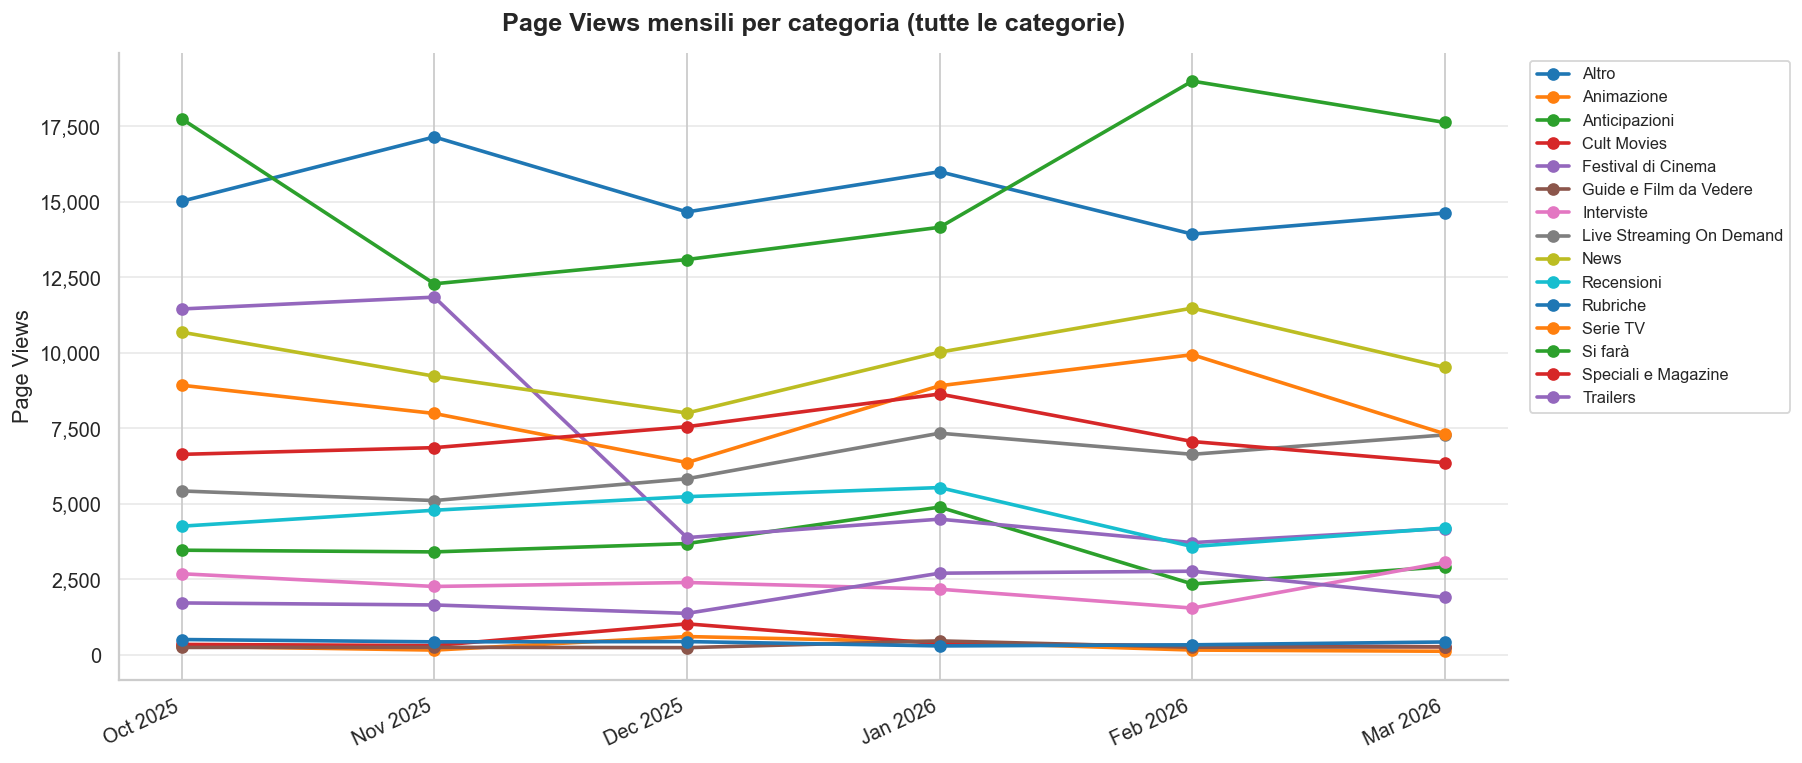

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = sns.color_palette("tab10", n_colors=len(pivot.columns))
x = range(len(pivot.index))

for i, col in enumerate(pivot.columns):
    ax.plot(x, pivot[col], marker="o", linewidth=2, label=col, color=colors[i])

ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index, rotation=25, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_title("Page Views mensili per categoria (tutte le categorie)", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Page Views")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=True)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

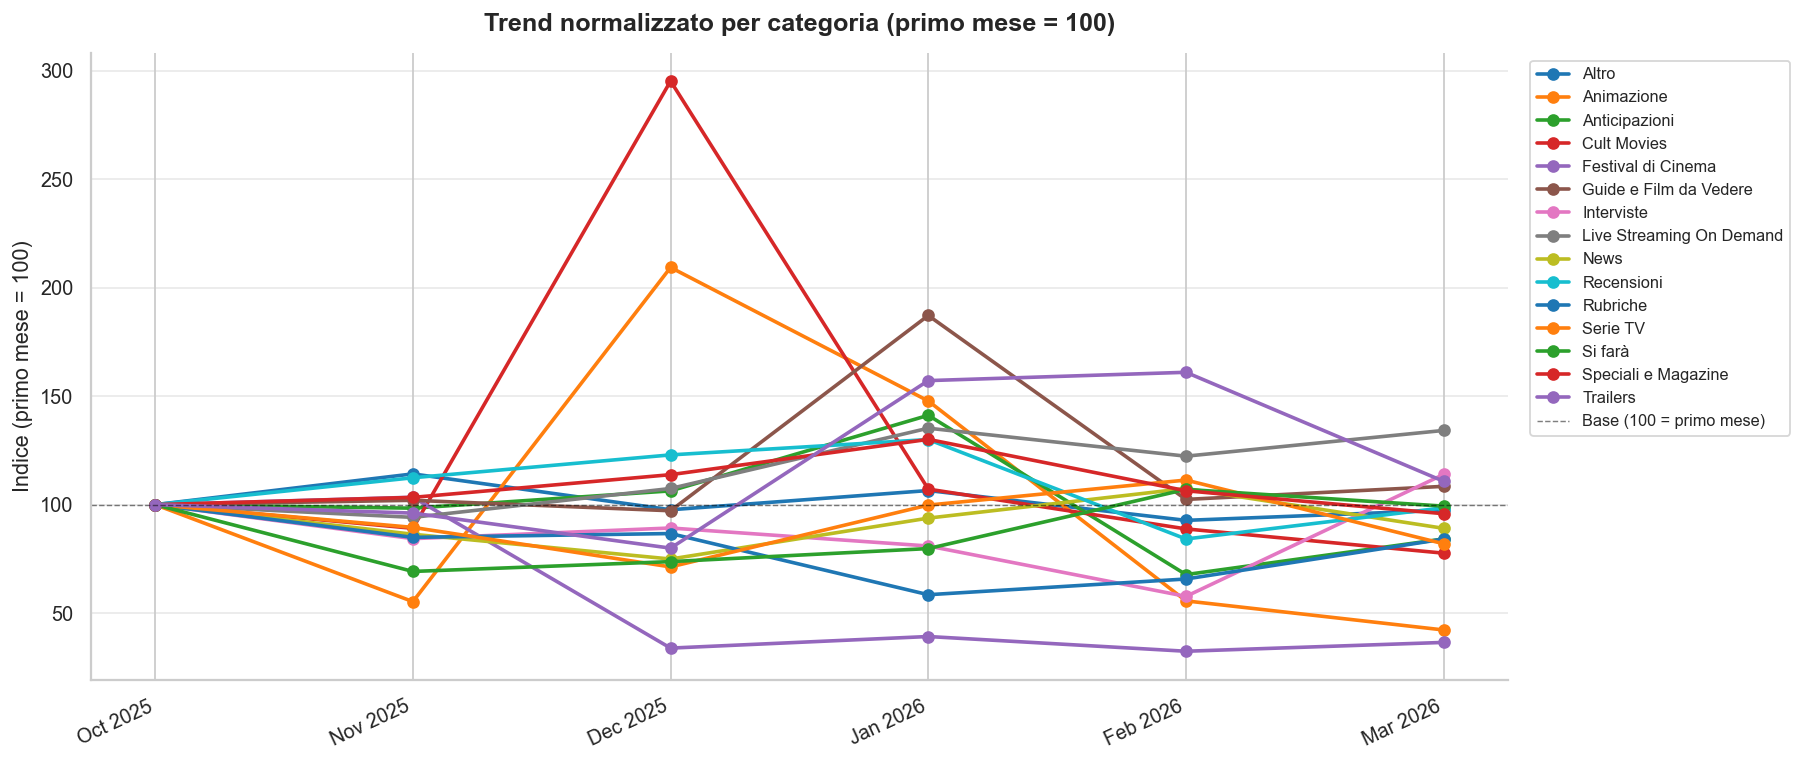

In [9]:
# -- Versione normalizzata (index 100 = primo mese): confronto della traiettoria
# indipendente dal volume assoluto
pivot_norm = pivot.div(pivot.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))

for i, col in enumerate(pivot_norm.columns):
    ax.plot(x, pivot_norm[col], marker="o", linewidth=2, label=col, color=colors[i])

ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.5, label="Base (100 = primo mese)")
ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index, rotation=25, ha="right")
ax.set_title("Trend normalizzato per categoria (primo mese = 100)", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Indice (primo mese = 100)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=True)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

## 7. Categoria con il calo maggiore — ranking e focus

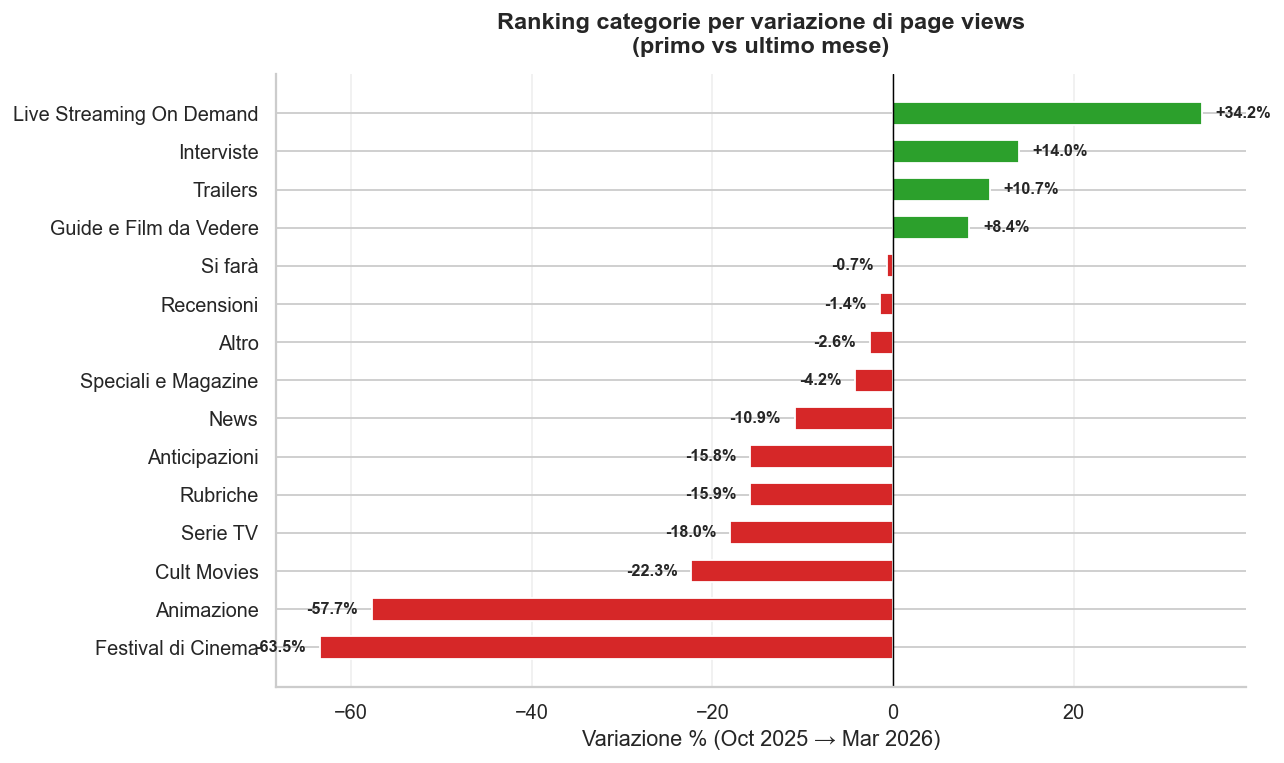


🔴 Categoria con il calo maggiore: Festival di Cinema  (-63.5%)


In [10]:
# --- Bar chart: ranking calo % dal primo all'ultimo mese ---
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ["#d62728" if v < 0 else "#2ca02c" for v in trend_df["delta_pct"]]
bars = ax.barh(trend_df.index, trend_df["delta_pct"], color=bar_colors, edgecolor="white", height=0.6)

# Annotazioni valore
for bar, val in zip(bars, trend_df["delta_pct"]):
    offset = -1.5 if val < 0 else 1.5
    ha = "right" if val < 0 else "left"
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%", va="center", ha=ha, fontsize=9, fontweight="bold")

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Variazione % ({pivot.index[0]} → {pivot.index[-1]})")
ax.set_title("Ranking categorie per variazione di page views\n(primo vs ultimo mese)", fontsize=13, fontweight="bold", pad=12)
ax.grid(axis="x", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

worst_cat = trend_df["delta_pct"].idxmin()
worst_val = trend_df.loc[worst_cat, "delta_pct"]
print(f"\n🔴 Categoria con il calo maggiore: {worst_cat}  ({worst_val:+.1f}%)")

C:\Users\manuel.deluzi\AppData\Local\Temp\ipykernel_26328\1520931634.py:27: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\manuel.deluzi\AppData\Local\Temp\ipykernel_26328\1520931634.py:27: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\manuel.deluzi\OneDrive - Havas\Projects\personali\taxi_drivers\.td_ds_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\manuel.deluzi\OneDrive - Havas\Projects\personali\taxi_drivers\.td_ds_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


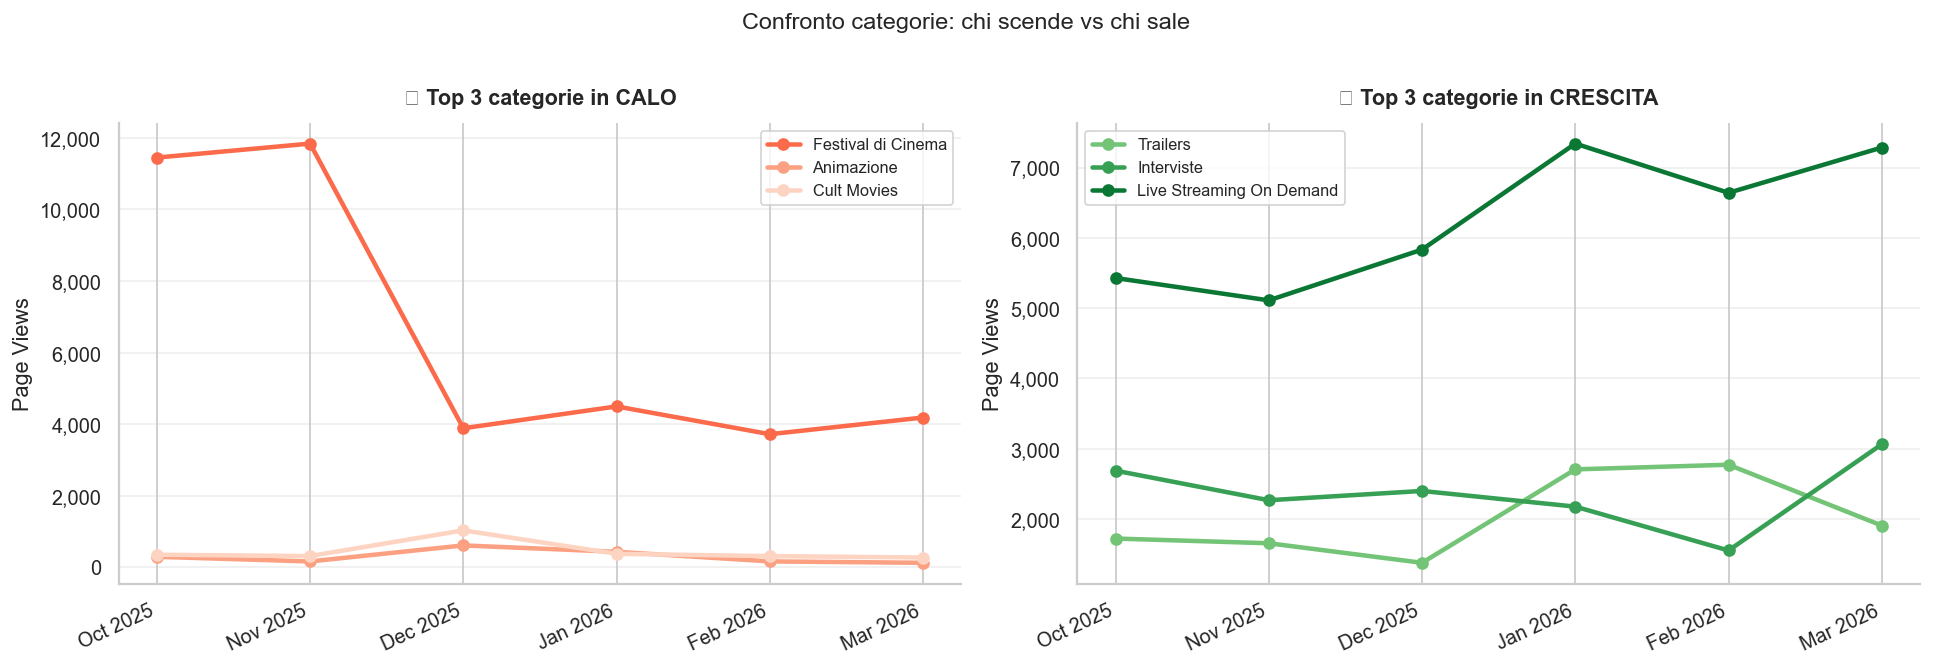

In [11]:
# --- Focus: top 3 categorie in calo vs top 3 in crescita ---
top_decline = trend_df.head(3).index.tolist()   # le 3 con il delta più negativo
top_growth  = trend_df.tail(3).index.tolist()   # le 3 con il delta più positivo
highlight   = top_decline + top_growth

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, group, title, cmap in zip(
    axes,
    [top_decline, top_growth],
    ["🔴 Top 3 categorie in CALO", "🟢 Top 3 categorie in CRESCITA"],
    ["Reds_r", "Greens"],
):
    palette = sns.color_palette(cmap, n_colors=len(group) + 2)[2:]
    for i, cat in enumerate(group):
        ax.plot(x, pivot[cat], marker="o", linewidth=2.5, label=cat, color=palette[i])
    ax.set_xticks(list(x))
    ax.set_xticklabels(pivot.index, rotation=25, ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_ylabel("Page Views")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle("Confronto categorie: chi scende vs chi sale", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

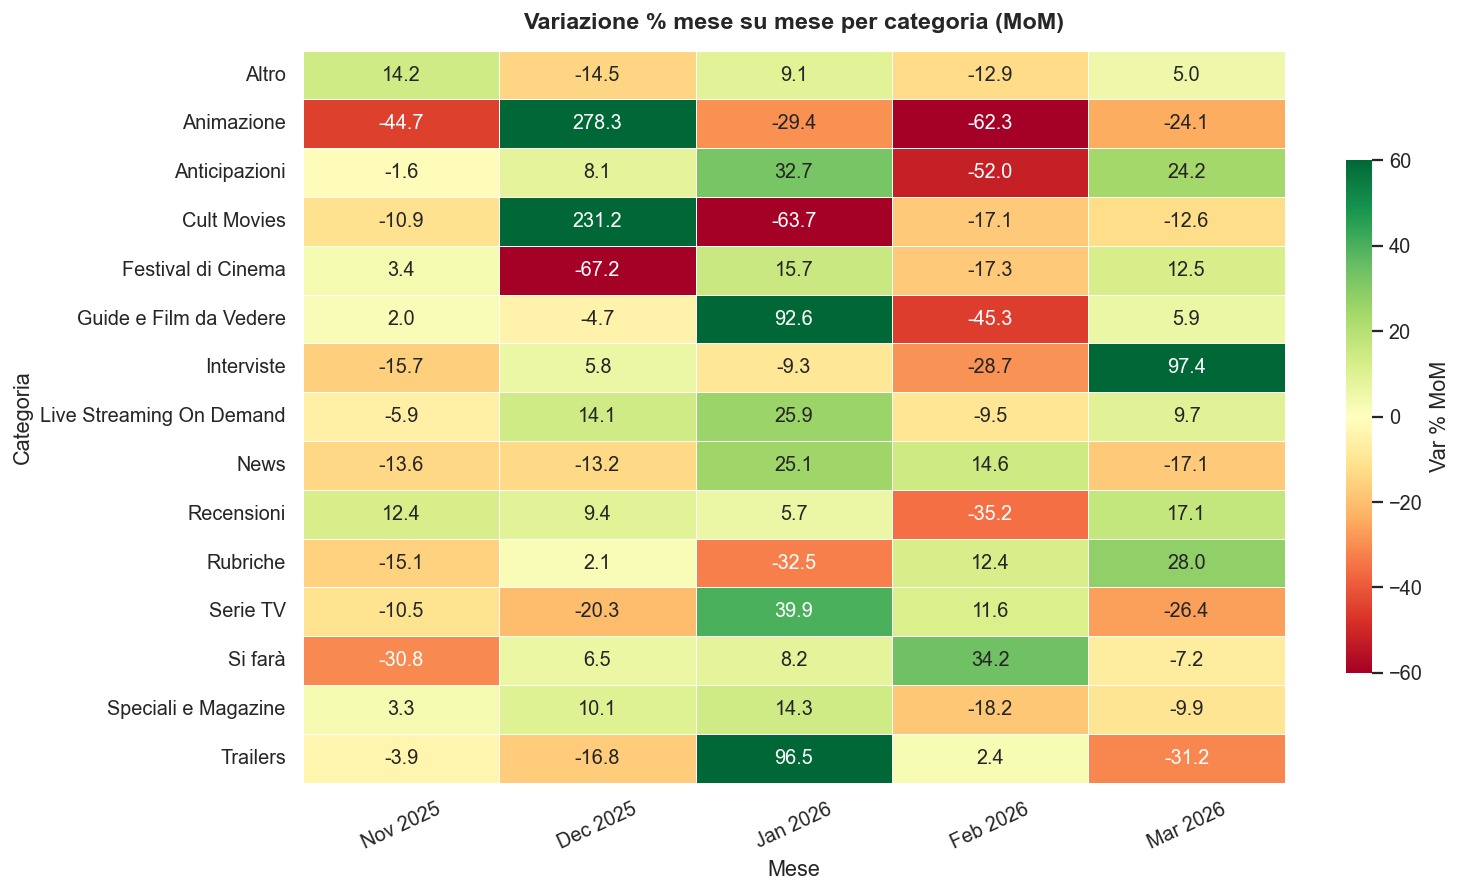

In [12]:
# --- Heatmap: variazione % mese su mese (month-over-month) ---
fig, ax = plt.subplots(figsize=(12, 7))

# Trasposta: categorie su Y, mesi su X (drop del primo che è NaN)
heatmap_data = pct_change.iloc[1:].T  # rimuove il primo mese (NaN per pct_change)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cmap="RdYlGn",
    center=0,
    vmin=-60,
    vmax=60,
    cbar_kws={"label": "Var % MoM", "shrink": 0.7},
    ax=ax,
)
ax.set_title("Variazione % mese su mese per categoria (MoM)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Mese")
ax.set_ylabel("Categoria")
ax.tick_params(axis="x", rotation=25)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

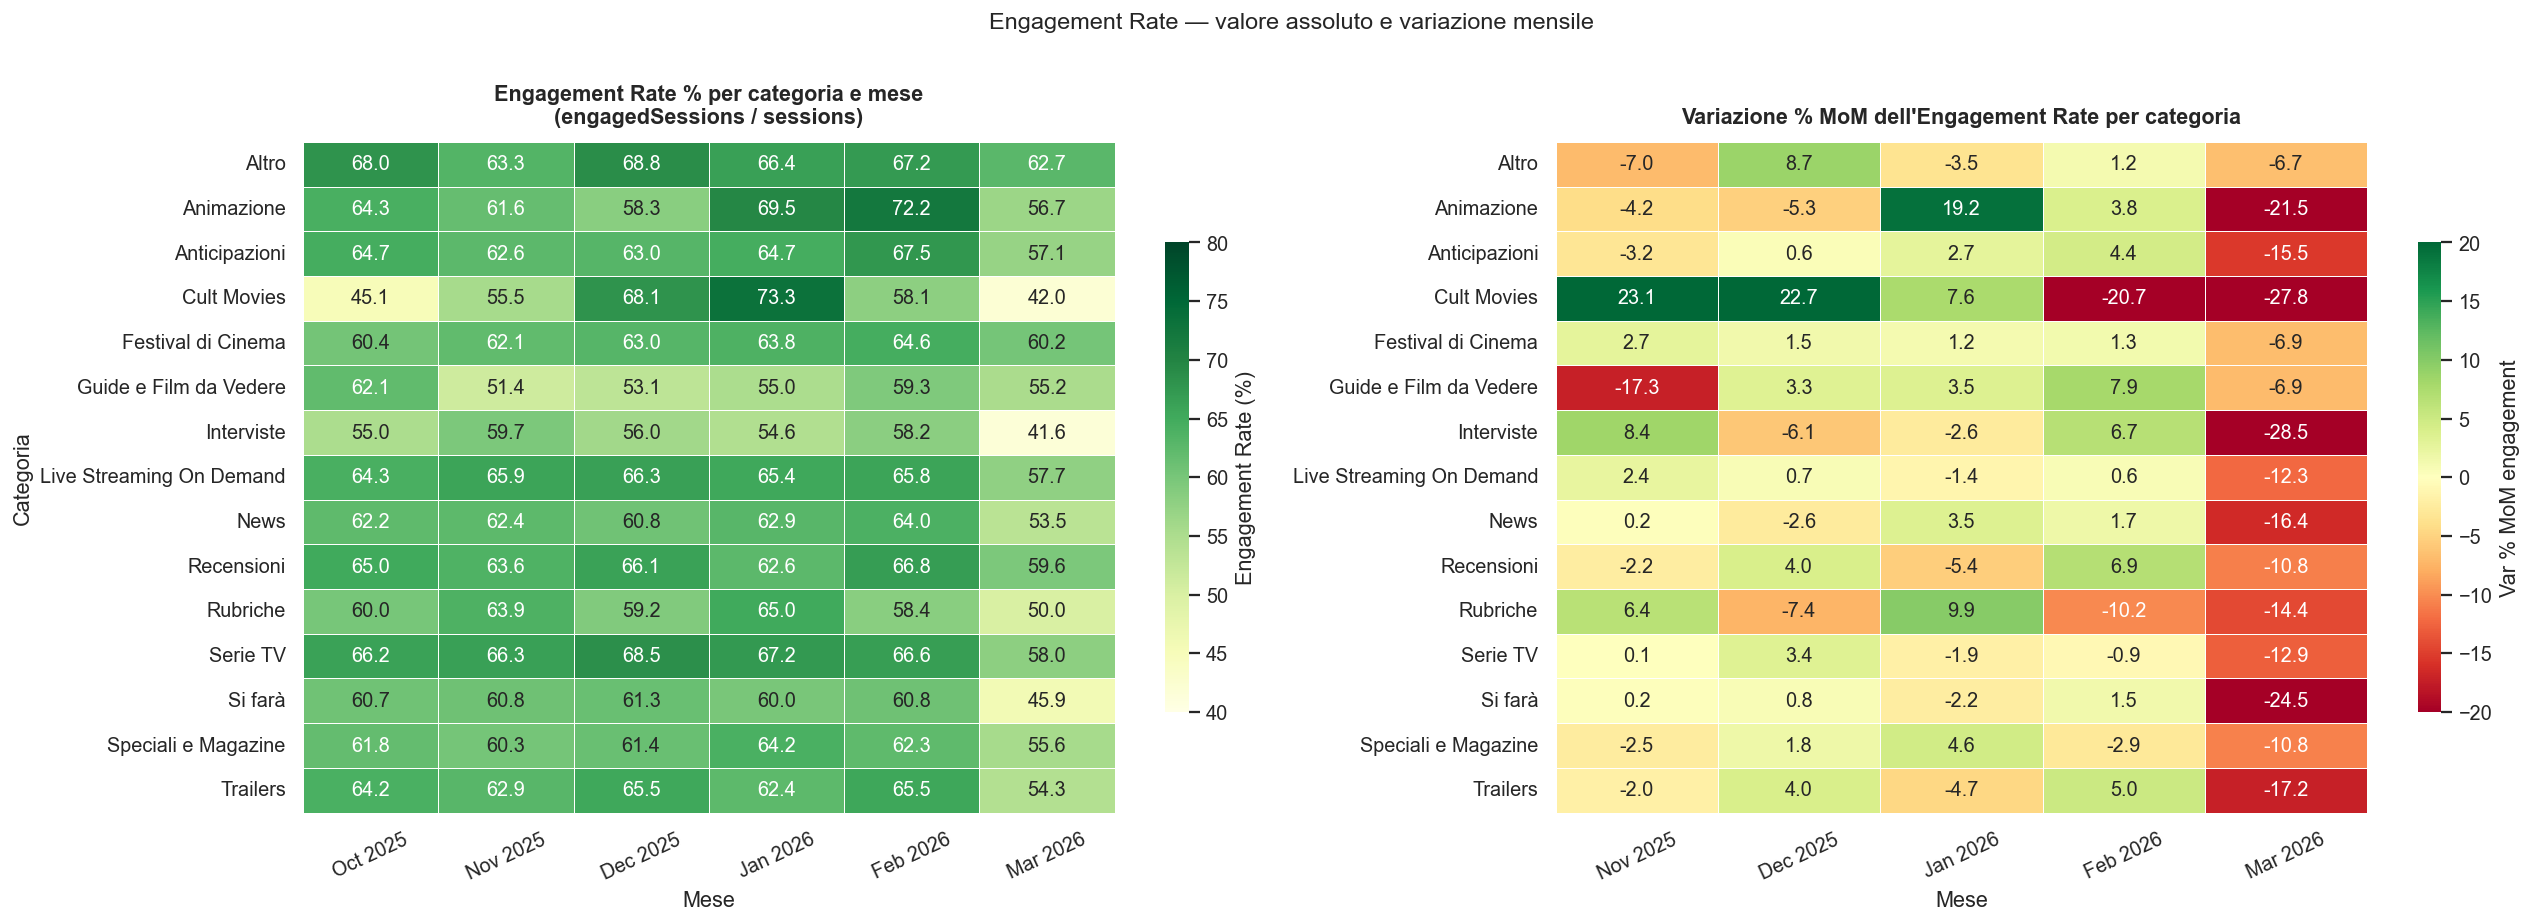

In [13]:
# --- Heatmap: engagement rate assoluto per mese (engagedSessions / sessions) ---

# Aggrega le sessioni per mese x categoria, poi calcola il ratio corretto
eng_agg = (
    df.groupby(["monthDate", "category"])[["totalEngagedSessions", "totalSessions"]]
    .sum()
)
pivot_eng = (
    (eng_agg["totalEngagedSessions"] / eng_agg["totalSessions"].replace(0, np.nan))
    .unstack("category")
    .sort_index()
)
pivot_eng.index = pivot_eng.index.strftime("%b %Y")

# Variazione % mese su mese sull'engagement rate
pct_change_eng = pivot_eng.pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# -- Sinistra: valore assoluto dell'engagement rate (in %) --
sns.heatmap(
    pivot_eng.T * 100,
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cmap="YlGn",
    vmin=40,
    vmax=80,
    cbar_kws={"label": "Engagement Rate (%)", "shrink": 0.7},
    ax=axes[0],
)
axes[0].set_title("Engagement Rate % per categoria e mese\n(engagedSessions / sessions)", fontsize=12, fontweight="bold", pad=10)
axes[0].set_xlabel("Mese")
axes[0].set_ylabel("Categoria")
axes[0].tick_params(axis="x", rotation=25)
axes[0].tick_params(axis="y", rotation=0)

# -- Destra: variazione MoM dell'engagement rate --
sns.heatmap(
    pct_change_eng.iloc[1:].T,
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cmap="RdYlGn",
    center=0,
    vmin=-20,
    vmax=20,
    cbar_kws={"label": "Var % MoM engagement", "shrink": 0.7},
    ax=axes[1],
)
axes[1].set_title("Variazione % MoM dell'Engagement Rate per categoria", fontsize=12, fontweight="bold", pad=10)
axes[1].set_xlabel("Mese")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=25)
axes[1].tick_params(axis="y", rotation=0)

plt.suptitle("Engagement Rate — valore assoluto e variazione mensile", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


📊 Engagement Rate - Analisi Marzo:
   • Reale (Marzo):     54.2%
   • Trend (Marzo):     59.1%
   • Differenza:        -4.9% (Sotto trend 🔴)


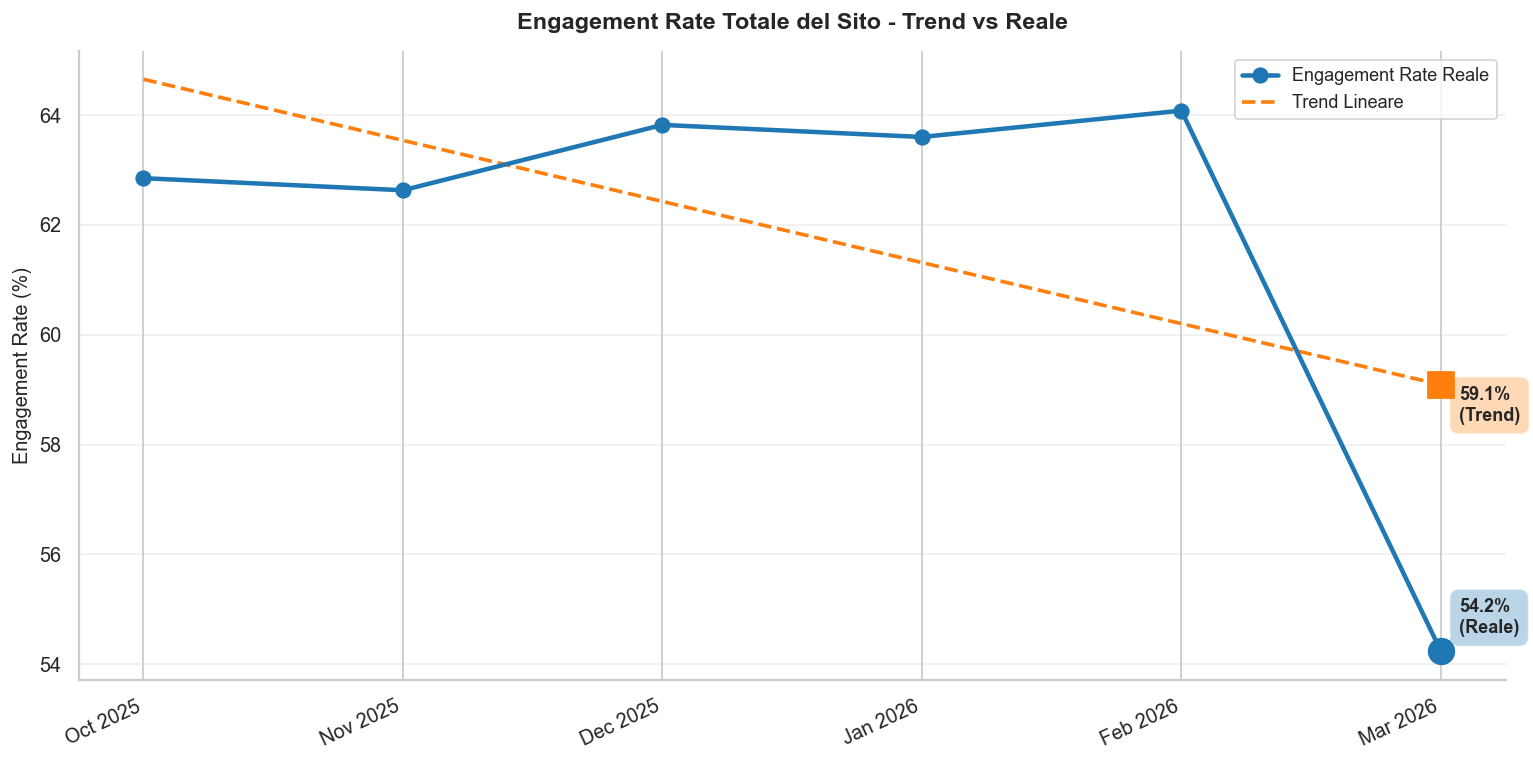


📋 Riepilogo Engagement Rate mensile:
    Mese  Engagement Rate (%)
Oct 2025                62.85
Nov 2025                62.63
Dec 2025                63.82
Jan 2026                63.60
Feb 2026                64.08
Mar 2026                54.24


In [14]:
# --- Trend engagement rate totale del sito per tutti i mesi - con confronto vs March ---

# Calcola engagement rate totale per ogni mese
monthly_eng = (
    df.groupby(["monthDate"])[["totalEngagedSessions", "totalSessions"]]
    .sum()
)
monthly_eng["engagement_rate"] = (monthly_eng["totalEngagedSessions"] / monthly_eng["totalSessions"] * 100).round(2)
monthly_eng_data = monthly_eng[["engagement_rate"]].reset_index()
monthly_eng_data.columns = ["monthDate", "engagement_rate"]
monthly_eng_data["month_str"] = monthly_eng_data["monthDate"].dt.strftime("%b %Y")

# Crea indice numerico per il trend (per la regressione)
monthly_eng_data["month_idx"] = range(1, len(monthly_eng_data) + 1)

# Calcola trend lineare
from numpy.polynomial import Polynomial
x = monthly_eng_data["month_idx"].values
y = monthly_eng_data["engagement_rate"].values
p = Polynomial.fit(x, y, 1)  # polinomio di grado 1 (linear trend)
trend_vals = p(x)

# Dati per il plot
x_months = range(len(monthly_eng_data))

fig, ax = plt.subplots(figsize=(12, 6))

# Linea del valore reale
ax.plot(x_months, y, marker="o", linewidth=2.5, markersize=8, label="Engagement Rate Reale", color="#1f77b4", zorder=3)

# Linea del trend
ax.plot(x_months, trend_vals, linewidth=2, linestyle="--", label="Trend Lineare", color="#ff7f0e", zorder=2)

# Evidenzia l'ultimo mese (marzo) se c'è un valore reale effettivo
if len(monthly_eng_data) > 0:
    last_idx = len(monthly_eng_data) - 1
    last_real = y[last_idx]
    last_trend = trend_vals[last_idx]
    
    # Segna il valore reale di marzo
    ax.scatter([last_idx], [last_real], s=200, color="#1f77b4", marker="o", zorder=5)
    ax.annotate(f"{last_real:.1f}%\n(Reale)", xy=(last_idx, last_real), xytext=(10, 10),
                textcoords="offset points", fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#1f77b4", alpha=0.3),
                arrowprops=dict(arrowstyle="->", color="#1f77b4"))
    
    # Segna il valore del trend per marzo
    ax.scatter([last_idx], [last_trend], s=200, color="#ff7f0e", marker="s", zorder=5)
    ax.annotate(f"{last_trend:.1f}%\n(Trend)", xy=(last_idx, last_trend), xytext=(10, -20),
                textcoords="offset points", fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#ff7f0e", alpha=0.3),
                arrowprops=dict(arrowstyle="->", color="#ff7f0e"))
    
    # Differenza tra reale e trend
    diff = last_real - last_trend
    print(f"\n📊 Engagement Rate - Analisi Marzo:")
    print(f"   • Reale (Marzo):     {last_real:.1f}%")
    print(f"   • Trend (Marzo):     {last_trend:.1f}%")
    print(f"   • Differenza:        {diff:+.1f}% ({('Sopra trend 🟢' if diff > 0 else 'Sotto trend 🔴')})")

ax.set_xticks(x_months)
ax.set_xticklabels(monthly_eng_data["month_str"], rotation=25, ha="right")
ax.set_ylabel("Engagement Rate (%)", fontsize=11)
ax.set_title("Engagement Rate Totale del Sito - Trend vs Reale", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10, loc="best")
ax.grid(axis="y", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# Mostra tabella con i valori
print("\n📋 Riepilogo Engagement Rate mensile:")
summary_table = monthly_eng_data[["month_str", "engagement_rate"]].copy()
summary_table.columns = ["Mese", "Engagement Rate (%)"]
print(summary_table.to_string(index=False))

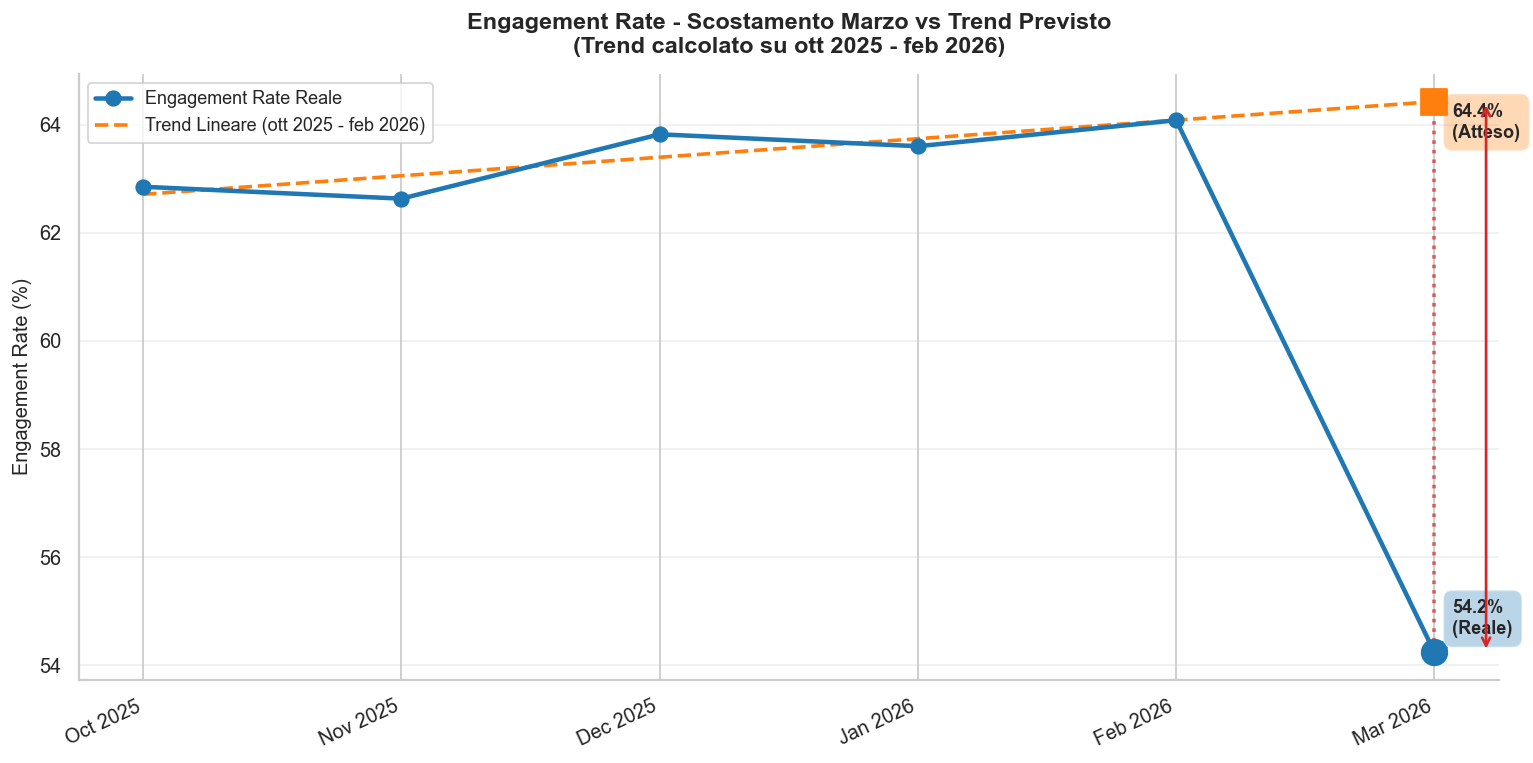


📊 Analisi Scostamento Marzo 2026:
   • Engagement Rate Atteso (da trend):     64.4%
   • Engagement Rate Reale (Marzo):         54.2%
   • Scostamento Assoluto:                  -10.2%
   • Scostamento Percentuale:               -15.8%
   • Status:                                🔴 SOTTO ATTESE

📋 Riepilogo con Trend Previsto:
    Mese  Valore Reale (%)  Trend Previsto (%)  Differenza (%)
Oct 2025             62.85               62.71           -0.14
Nov 2025             62.63               63.05            0.42
Dec 2025             63.82               63.40           -0.42
Jan 2026             63.60               63.74            0.14
Feb 2026             64.08               64.08            0.00
Mar 2026             54.24               64.42           10.18


In [15]:
# --- Trend engagement rate ESCLUDENDO marzo 2026 (trend fino a febbraio) ---

# Dati fino a febbraio (escludendo marzo)
monthly_eng_data_no_march = monthly_eng_data[monthly_eng_data["month_idx"] < len(monthly_eng_data)].copy()

# Calcola trend lineare usando solo fino a febbraio
x_trend_data = monthly_eng_data_no_march["month_idx"].values
y_trend_data = monthly_eng_data_no_march["engagement_rate"].values

# Fit polinomio di grado 1 (linear trend) SOLO fino a febbraio
p_no_march = Polynomial.fit(x_trend_data, y_trend_data, 1)

# Estendi il trend anche per marzo (month_idx = 6)
x_all_months = monthly_eng_data["month_idx"].values
trend_vals_extended = p_no_march(x_all_months)

# Dati per il plot
x_months = range(len(monthly_eng_data))
y_all = monthly_eng_data["engagement_rate"].values

fig, ax = plt.subplots(figsize=(12, 6))

# Linea del valore reale (tutti i mesi)
ax.plot(x_months, y_all, marker="o", linewidth=2.5, markersize=8, label="Engagement Rate Reale", color="#1f77b4", zorder=3)

# Linea del trend (calcolato SENZA marzo, ma esteso fino a marzo)
ax.plot(x_months, trend_vals_extended, linewidth=2, linestyle="--", label="Trend Lineare (ott 2025 - feb 2026)", color="#ff7f0e", zorder=2)

# Evidenzia marzo
march_idx = len(monthly_eng_data) - 1
march_real = y_all[march_idx]
march_trend = trend_vals_extended[march_idx]

# Segna il valore reale di marzo
ax.scatter([march_idx], [march_real], s=200, color="#1f77b4", marker="o", zorder=5)
ax.annotate(f"{march_real:.1f}%\n(Reale)", xy=(march_idx, march_real), xytext=(10, 10),
            textcoords="offset points", fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#1f77b4", alpha=0.3),
            arrowprops=dict(arrowstyle="->", color="#1f77b4"))

# Segna il valore del trend per marzo (previsione)
ax.scatter([march_idx], [march_trend], s=200, color="#ff7f0e", marker="s", zorder=5)
ax.annotate(f"{march_trend:.1f}%\n(Atteso)", xy=(march_idx, march_trend), xytext=(10, -20),
            textcoords="offset points", fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#ff7f0e", alpha=0.3),
            arrowprops=dict(arrowstyle="->", color="#ff7f0e"))

# Disegna una linea verticale per mostrare lo scostamento
ax.plot([march_idx, march_idx], [march_trend, march_real], linewidth=2, linestyle=":", color="#d62728", zorder=4, alpha=0.7)
ax.annotate("", xy=(march_idx + 0.2, march_real), xytext=(march_idx + 0.2, march_trend),
            arrowprops=dict(arrowstyle="<->", color="#d62728", lw=1.5))

ax.set_xticks(x_months)
ax.set_xticklabels(monthly_eng_data["month_str"], rotation=25, ha="right")
ax.set_ylabel("Engagement Rate (%)", fontsize=11)
ax.set_title("Engagement Rate - Scostamento Marzo vs Trend Previsto\n(Trend calcolato su ott 2025 - feb 2026)", 
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10, loc="best")
ax.grid(axis="y", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# Analisi dello scostamento
diff = march_real - march_trend
pct_diff = (diff / march_trend) * 100

print(f"\n📊 Analisi Scostamento Marzo 2026:")
print(f"   • Engagement Rate Atteso (da trend):     {march_trend:.1f}%")
print(f"   • Engagement Rate Reale (Marzo):         {march_real:.1f}%")
print(f"   • Scostamento Assoluto:                  {diff:+.1f}%")
print(f"   • Scostamento Percentuale:               {pct_diff:+.1f}%")
print(f"   • Status:                                {'🔴 SOTTO ATTESE' if diff < 0 else '🟢 SOPRA ATTESE'}")

print(f"\n📋 Riepilogo con Trend Previsto:")
comparison_table = monthly_eng_data[["month_str", "engagement_rate"]].copy()
comparison_table.columns = ["Mese", "Valore Reale (%)"]
comparison_table["Trend Previsto (%)"] = trend_vals_extended.round(2)
comparison_table["Differenza (%)"] = (trend_vals_extended - y_all).round(2)
print(comparison_table.to_string(index=False))

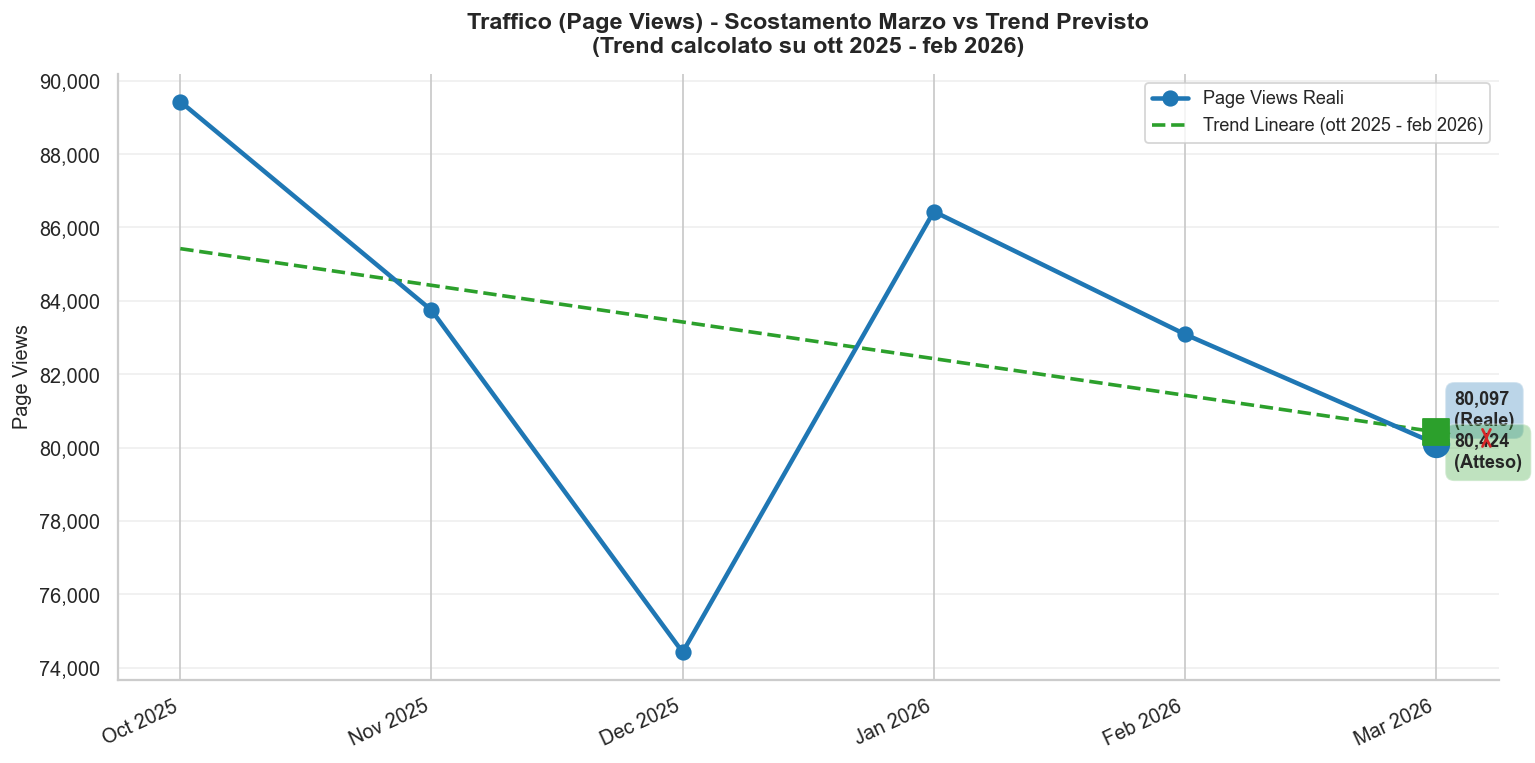


📊 Analisi Scostamento Traffico Marzo 2026:
   • Page Views Attesi (da trend):           80,424
   • Page Views Reali (Marzo):               80,097
   • Scostamento Assoluto:                   -327 views
   • Scostamento Percentuale:                -0.4%
   • Status:                                 🔴 SOTTO ATTESE

📋 Riepilogo Page Views con Trend Previsto:
    Mese  Valore Reale  Trend Previsto  Differenza
Oct 2025         89427           85420       -4007
Nov 2025         83742           84421         679
Dec 2025         74421           83422        9001
Jan 2026         86432           82422       -4010
Feb 2026         83086           81423       -1663
Mar 2026         80097           80424         327


In [23]:
# --- Trend traffico (Page Views totali) ESCLUDENDO marzo 2026 (trend fino a febbraio) ---

# Calcola total page views per ogni mese
monthly_pv = (
    df.groupby(["monthDate"])[["totalPageViews"]]
    .sum()
)
monthly_pv_data = monthly_pv.reset_index()
monthly_pv_data.columns = ["monthDate", "totalPageViews"]
monthly_pv_data["month_str"] = monthly_pv_data["monthDate"].dt.strftime("%b %Y")
monthly_pv_data["month_idx"] = range(1, len(monthly_pv_data) + 1)

# Calcola trend lineare usando solo fino a febbraio
pv_trend_data = monthly_pv_data[monthly_pv_data["month_idx"] < len(monthly_pv_data)].copy()
x_pv_trend = pv_trend_data["month_idx"].values
y_pv_trend = pv_trend_data["totalPageViews"].values

# Fit polinomio di grado 1 (linear trend) SOLO fino a febbraio
p_pv_no_march = Polynomial.fit(x_pv_trend, y_pv_trend, 1)

# Estendi il trend anche per marzo
x_pv_all = monthly_pv_data["month_idx"].values
pv_trend_vals_extended = p_pv_no_march(x_pv_all)

# Dati per il plot
x_pv_months = range(len(monthly_pv_data))
y_pv_all = monthly_pv_data["totalPageViews"].values

fig, ax = plt.subplots(figsize=(12, 6))

# Linea del valore reale (tutti i mesi)
ax.plot(x_pv_months, y_pv_all, marker="o", linewidth=2.5, markersize=8, label="Page Views Reali", color="#1f77b4", zorder=3)

# Linea del trend (calcolato SENZA marzo, ma esteso fino a marzo)
ax.plot(x_pv_months, pv_trend_vals_extended, linewidth=2, linestyle="--", label="Trend Lineare (ott 2025 - feb 2026)", color="#2ca02c", zorder=2)

# Evidenzia marzo
march_pv_idx = len(monthly_pv_data) - 1
march_pv_real = y_pv_all[march_pv_idx]
march_pv_trend = pv_trend_vals_extended[march_pv_idx]

# Segna il valore reale di marzo
ax.scatter([march_pv_idx], [march_pv_real], s=200, color="#1f77b4", marker="o", zorder=5)
ax.annotate(f"{march_pv_real:,.0f}\n(Reale)", xy=(march_pv_idx, march_pv_real), xytext=(10, 10),
            textcoords="offset points", fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#1f77b4", alpha=0.3),
            arrowprops=dict(arrowstyle="->", color="#1f77b4"))

# Segna il valore del trend per marzo (previsione)
ax.scatter([march_pv_idx], [march_pv_trend], s=200, color="#2ca02c", marker="s", zorder=5)
ax.annotate(f"{march_pv_trend:,.0f}\n(Atteso)", xy=(march_pv_idx, march_pv_trend), xytext=(10, -20),
            textcoords="offset points", fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#2ca02c", alpha=0.3),
            arrowprops=dict(arrowstyle="->", color="#2ca02c"))

# Disegna una linea verticale per mostrare lo scostamento
ax.plot([march_pv_idx, march_pv_idx], [march_pv_trend, march_pv_real], linewidth=2, linestyle=":", color="#d62728", zorder=4, alpha=0.7)
ax.annotate("", xy=(march_pv_idx + 0.2, march_pv_real), xytext=(march_pv_idx + 0.2, march_pv_trend),
            arrowprops=dict(arrowstyle="<->", color="#d62728", lw=1.5))

ax.set_xticks(x_pv_months)
ax.set_xticklabels(monthly_pv_data["month_str"], rotation=25, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_ylabel("Page Views", fontsize=11)
ax.set_title("Traffico (Page Views) - Scostamento Marzo vs Trend Previsto\n(Trend calcolato su ott 2025 - feb 2026)", 
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10, loc="best")
ax.grid(axis="y", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# Analisi dello scostamento
pv_diff = march_pv_real - march_pv_trend
pv_pct_diff = (pv_diff / march_pv_trend) * 100

print(f"\n📊 Analisi Scostamento Traffico Marzo 2026:")
print(f"   • Page Views Attesi (da trend):           {march_pv_trend:,.0f}")
print(f"   • Page Views Reali (Marzo):               {march_pv_real:,.0f}")
print(f"   • Scostamento Assoluto:                   {pv_diff:+,.0f} views")
print(f"   • Scostamento Percentuale:                {pv_pct_diff:+.1f}%")
print(f"   • Status:                                 {'🔴 SOTTO ATTESE' if pv_diff < 0 else '🟢 SOPRA ATTESE'}")

print(f"\n📋 Riepilogo Page Views con Trend Previsto:")
pv_comparison_table = monthly_pv_data[["month_str", "totalPageViews"]].copy()
pv_comparison_table.columns = ["Mese", "Valore Reale"]
pv_comparison_table["Trend Previsto"] = pv_trend_vals_extended.round(0).astype(int)
pv_comparison_table["Differenza"] = (pv_trend_vals_extended - y_pv_all).round(0).astype(int)
print(pv_comparison_table.to_string(index=False))

## 8. Focus: Festival di Cinema - Andamento degli Articoli

📺 FOCUS: Andamento Festival di Cinema

📋 Dati Mensili Completi:
         Mese  N° Articoli  Page Views  Active Users  Avg ER %
 Ottobre 2025          380       11451          8191    0.6045
Novembre 2025          456       11842          8047    0.6211
Dicembre 2025          156        3884          2589    0.6304
 Gennaio 2026          138        4495          3271    0.6382
Febbraio 2026          138        3718          2748    0.6462
   Marzo 2026          164        4184          2903    0.6018

📊 Statistiche Descrittive per il Periodo:
   • Numero totale di articoli:     1432
   • Media articoli/mese:           238.7
   • Min articoli (in un mese):     138
   • Max articoli (in un mese):     456
   • Totale Page Views:             39,574
   • Media PV/mese:                 6,596
   • Engagement Rate Reale Medio:   62.37%
   • PV medi per articolo:          28


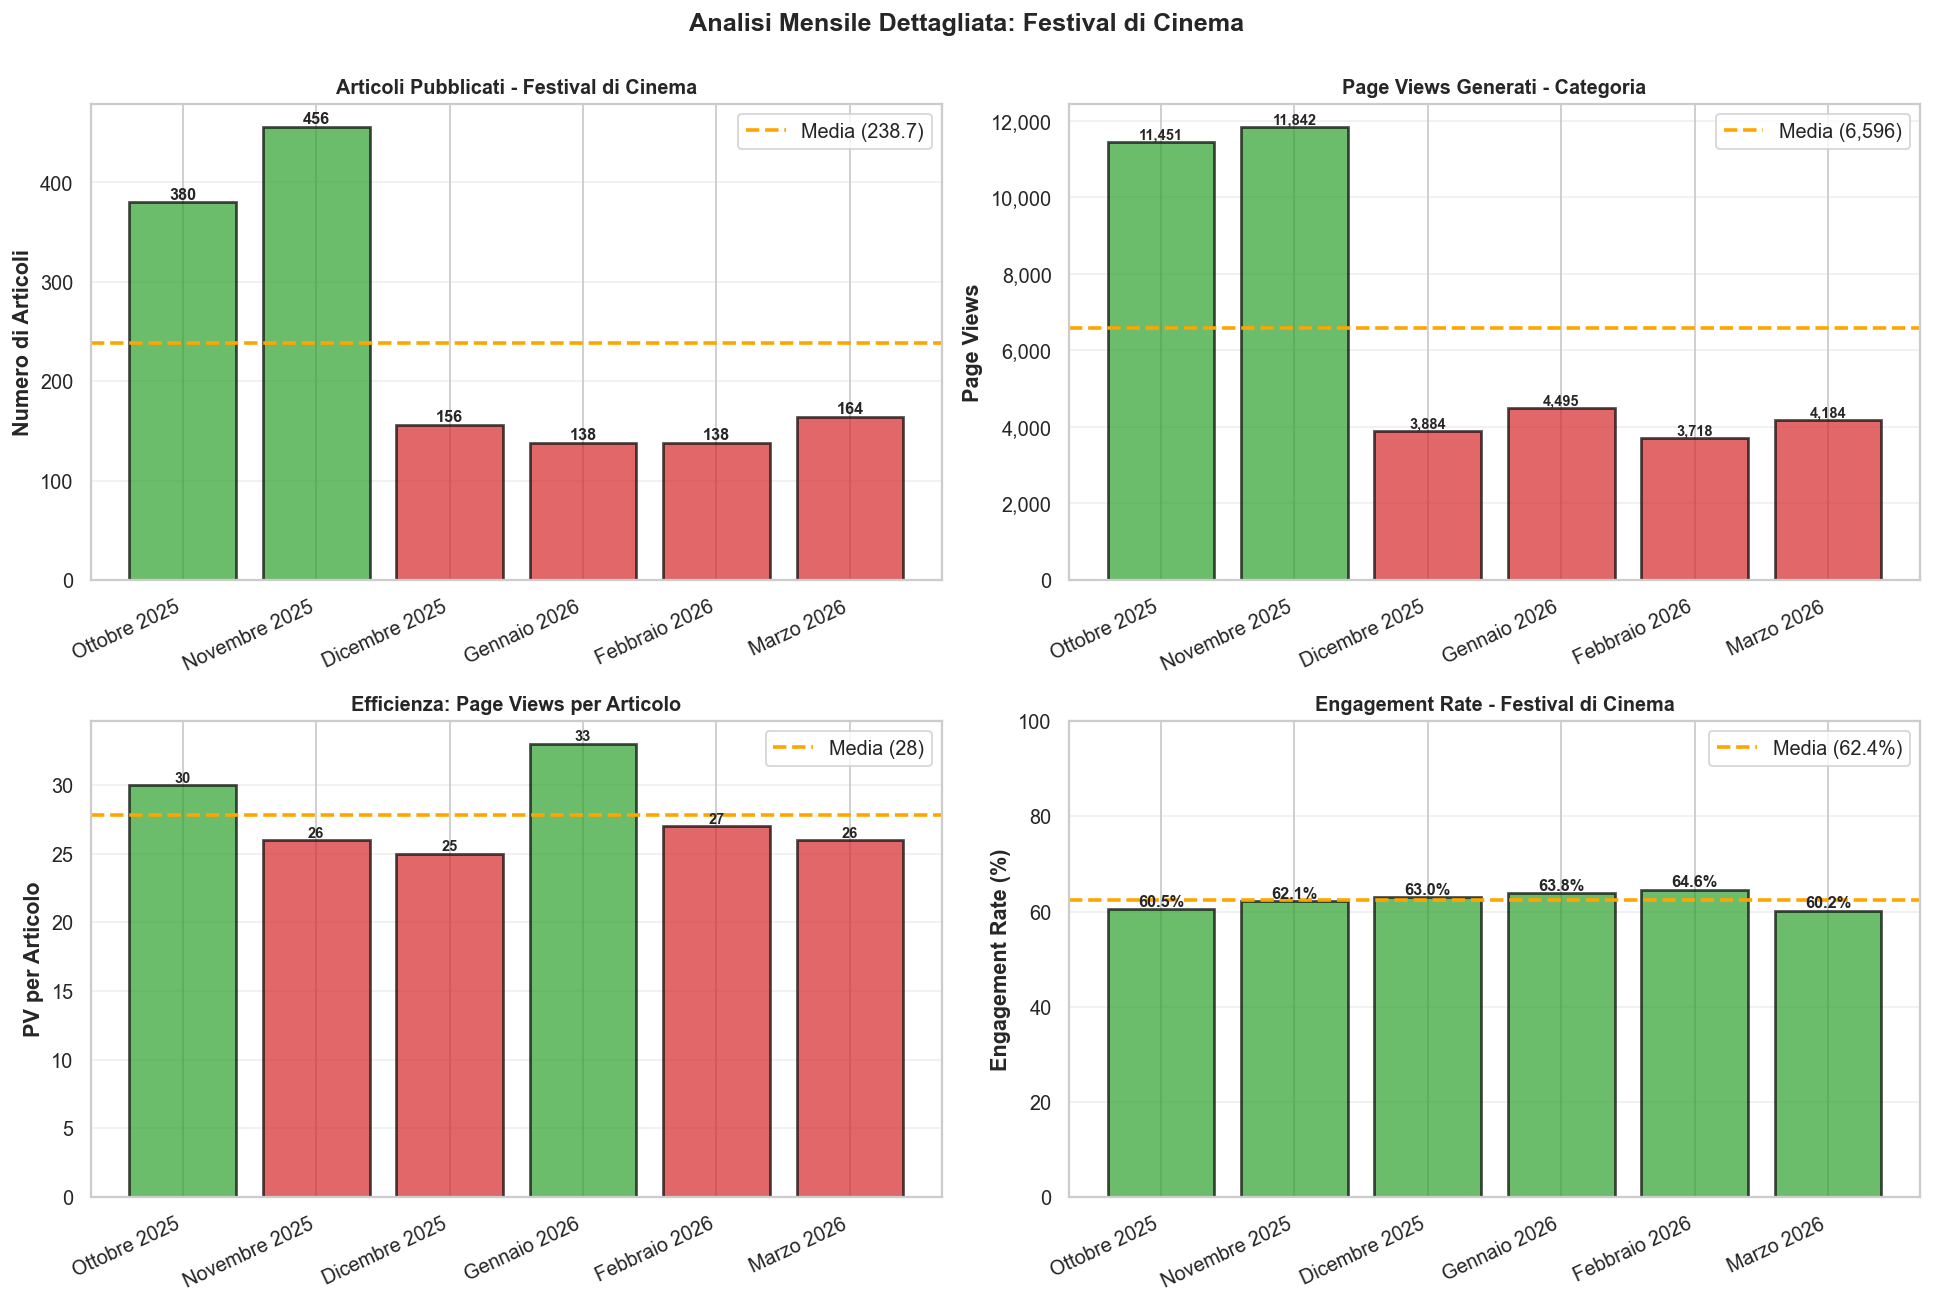


🎬 Focus Marzo 2026 vs Media Periodo:


In [29]:
# --- Focus: Andamento Articoli Festival di Cinema per Mese (usando articleCount) ---

cinema_category = 'Festival di Cinema'

# Filtra dataset per Festival di Cinema
cinema_data = df[df['category'] == cinema_category].copy().sort_values('monthDate')

print(f"📺 FOCUS: Andamento {cinema_category}\n")
print(f"📋 Dati Mensili Completi:")
display_cols = ['monthLabel', 'articleCount', 'totalPageViews', 'totalActiveUsers', 'avgEngagementRate']
cinema_display = cinema_data[display_cols].copy()
cinema_display.columns = ['Mese', 'N° Articoli', 'Page Views', 'Active Users', 'Avg ER %']
print(cinema_display.to_string(index=False))

# Statistiche descrittive
print(f"\n📊 Statistiche Descrittive per il Periodo:")
print(f"   • Numero totale di articoli:     {cinema_data['articleCount'].sum()}")
print(f"   • Media articoli/mese:           {cinema_data['articleCount'].mean():.1f}")
print(f"   • Min articoli (in un mese):     {cinema_data['articleCount'].min()}")
print(f"   • Max articoli (in un mese):     {cinema_data['articleCount'].max()}")
print(f"   • Totale Page Views:             {cinema_data['totalPageViews'].sum():,.0f}")
print(f"   • Media PV/mese:                 {cinema_data['totalPageViews'].mean():,.0f}")

# Calcola engagement rate reale per categoria
cinema_data['eng_rate'] = (cinema_data['totalEngagedSessions'] / cinema_data['totalSessions'] * 100).round(2)
print(f"   • Engagement Rate Reale Medio:   {cinema_data['eng_rate'].mean():.2f}%")

# Efficienza
cinema_data['avg_pv_per_article'] = (cinema_data['totalPageViews'] / cinema_data['articleCount']).round(0)
print(f"   • PV medi per articolo:          {cinema_data['avg_pv_per_article'].mean():,.0f}")

# Crea visualizzazioni
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

x_pos = range(len(cinema_data))
months_labels = cinema_data['monthLabel'].tolist()

# 1. Numero di articoli per mese
ax1 = axes[0, 0]
colors_articles = ['#d62728' if x < cinema_data['articleCount'].mean() else '#2ca02c' 
                   for x in cinema_data['articleCount']]
bars1 = ax1.bar(x_pos, cinema_data['articleCount'], 
                color=colors_articles, edgecolor='black', linewidth=1.5, alpha=0.7)
ax1.axhline(cinema_data['articleCount'].mean(), color='orange', linestyle='--', 
            linewidth=2, label=f"Media ({cinema_data['articleCount'].mean():.1f})")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(months_labels, rotation=25, ha='right')
ax1.set_ylabel('Numero di Articoli', fontweight='bold')
ax1.set_title(f'Articoli Pubblicati - {cinema_category}', fontweight='bold', fontsize=11)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, cinema_data['articleCount']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(val)}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. Page Views per mese
ax2 = axes[0, 1]
colors_pv = ['#d62728' if x < cinema_data['totalPageViews'].mean() else '#2ca02c' 
             for x in cinema_data['totalPageViews']]
bars2 = ax2.bar(x_pos, cinema_data['totalPageViews'], 
                color=colors_pv, edgecolor='black', linewidth=1.5, alpha=0.7)
ax2.axhline(cinema_data['totalPageViews'].mean(), color='orange', linestyle='--', 
            linewidth=2, label=f"Media ({cinema_data['totalPageViews'].mean():,.0f})")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(months_labels, rotation=25, ha='right')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax2.set_ylabel('Page Views', fontweight='bold')
ax2.set_title('Page Views Generati - Categoria', fontweight='bold', fontsize=11)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, cinema_data['totalPageViews']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(val):,}', ha='center', va='bottom', fontweight='bold', fontsize=8)

# 3. PV per Articolo (efficienza)
ax3 = axes[1, 0]
colors_eff = ['#d62728' if x < cinema_data['avg_pv_per_article'].mean() else '#2ca02c' 
              for x in cinema_data['avg_pv_per_article']]
bars3 = ax3.bar(x_pos, cinema_data['avg_pv_per_article'], 
                color=colors_eff, edgecolor='black', linewidth=1.5, alpha=0.7)
ax3.axhline(cinema_data['avg_pv_per_article'].mean(), color='orange', linestyle='--', 
            linewidth=2, label=f"Media ({cinema_data['avg_pv_per_article'].mean():,.0f})")
ax3.set_xticks(x_pos)
ax3.set_xticklabels(months_labels, rotation=25, ha='right')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax3.set_ylabel('PV per Articolo', fontweight='bold')
ax3.set_title('Efficienza: Page Views per Articolo', fontweight='bold', fontsize=11)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, cinema_data['avg_pv_per_article']):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(val):,}', ha='center', va='bottom', fontweight='bold', fontsize=8)

# 4. Engagement Rate per categoria (reale)
ax4 = axes[1, 1]
colors_eng = ['#d62728' if x < 60 else '#2ca02c' for x in cinema_data['eng_rate']]
bars4 = ax4.bar(x_pos, cinema_data['eng_rate'], 
                color=colors_eng, edgecolor='black', linewidth=1.5, alpha=0.7)
ax4.axhline(cinema_data['eng_rate'].mean(), color='orange', linestyle='--', 
            linewidth=2, label=f"Media ({cinema_data['eng_rate'].mean():.1f}%)")
ax4.set_xticks(x_pos)
ax4.set_xticklabels(months_labels, rotation=25, ha='right')
ax4.set_ylabel('Engagement Rate (%)', fontweight='bold')
ax4.set_ylim(0, 100)
ax4.set_title(f'Engagement Rate - {cinema_category}', fontweight='bold', fontsize=11)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
for bar, val in zip(bars4, cinema_data['eng_rate']):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle(f'Analisi Mensile Dettagliata: {cinema_category}', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Analisi del trend in marzo
print(f"\n🎬 Focus Marzo 2026 vs Media Periodo:")
march_data = cinema_data[cinema_data['monthLabel'] == 'Mar 2026']
if not march_data.empty:
    march_articles = march_data['articleCount'].values[0]
    march_pv = march_data['totalPageViews'].values[0]
    march_eng = march_data['eng_rate'].values[0]
    
    avg_articles = cinema_data['articleCount'].mean()
    avg_pv = cinema_data['totalPageViews'].mean()
    avg_eng = cinema_data['eng_rate'].mean()
    
    print(f"   • Articoli: {march_articles} (media: {avg_articles:.1f}) → {((march_articles-avg_articles)/avg_articles*100):+.1f}%")
    print(f"   • Page Views: {march_pv:,.0f} (media: {avg_pv:,.0f}) → {((march_pv-avg_pv)/avg_pv*100):+.1f}%")
    print(f"   • Engagement: {march_eng:.2f}% (media: {avg_eng:.2f}%) → {(march_eng-avg_eng):+.2f}% pp")
    
    # Analisi PV per articolo
    march_pv_per_article = march_data['avg_pv_per_article'].values[0]
    avg_pv_per_article = cinema_data['avg_pv_per_article'].mean()
    print(f"   • PV/Articolo: {march_pv_per_article:,.0f} (media: {avg_pv_per_article:,.0f}) → {((march_pv_per_article-avg_pv_per_article)/avg_pv_per_article*100):+.1f}%")

## 9. Correlazione: Articoli Festival di Cinema vs Page Views Totali


📊 CORRELAZIONE: Articoli Festival di Cinema vs Page Views Totali

📈 Coefficiente di Correlazione (Pearson r): 0.4461
   • Tipo: 🟢 POSITIVA (forte)
   • P-value: 0.3753 (NON significativo @ α=0.05)
   • R² (varianza spiegata): 0.1990 (19.9%)

🔍 Interpretazione:
   Quando Festival di Cinema pubblica PIÙ articoli, i page views totali tendono a SALIRE

📐 Regressione Lineare:
   • Slope (pendenza): +16.43
   • Intercept: 78,945
   • Equazione: PV_totali = 78,945 + +16.43 × (articoli_cinema)
   • Std Error: +16.49


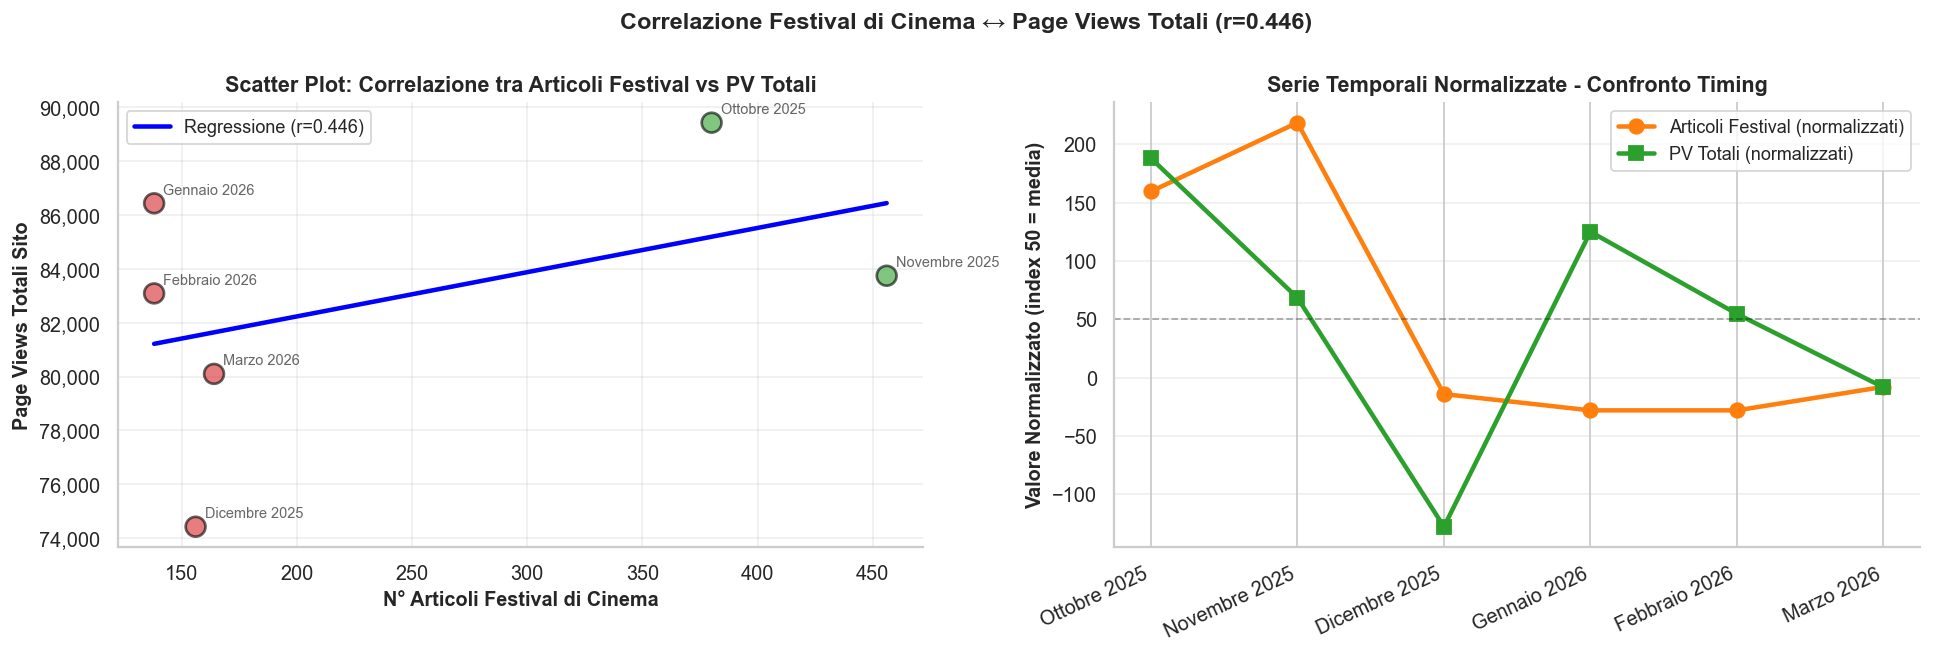


📋 Dati Dettagliati per Mese:
         Mese  Articoli Festival  PV Totali  PV/Articolo
 Ottobre 2025                380      89427          235
Novembre 2025                456      83742          183
Dicembre 2025                156      74421          477
 Gennaio 2026                138      86432          626
Febbraio 2026                138      83086          602
   Marzo 2026                164      80097          488


In [31]:
from scipy import stats

# --- Correlazione: Articoli Festival di Cinema vs Page Views Totali ---

# Prepara i dati:
# - X: numero articoli Festival di Cinema per mese
# - Y: page views TOTALI del sito per mese

cinema_articles = cinema_data.sort_values('monthDate')['articleCount'].values
total_pv = monthly_pv_data.sort_values('monthDate')['totalPageViews'].values

# Assicura che i vettori abbiano la stessa lunghezza (per sicurezza)
min_len = min(len(cinema_articles), len(total_pv))
x_articles = cinema_articles[:min_len]
y_total_pv = total_pv[:min_len]

# Calcola correlazione lineare (Pearson)
r_coef, p_value_corr = stats.pearsonr(x_articles, y_total_pv)

# Regressione lineare
slope_corr, intercept_corr, r_value_corr, p_value_reg, std_err_corr = stats.linregress(x_articles, y_total_pv)

# Interpretazione della correlazione
if r_coef < 0:
    corr_type = "🔴 NEGATIVA (inversa)"
    interpretation = "Quando Festival di Cinema pubblica MENO articoli, i page views totali tendono a SALIRE (e vice versa)"
elif r_coef > 0.3:
    corr_type = "🟢 POSITIVA (forte)"
    interpretation = "Quando Festival di Cinema pubblica PIÙ articoli, i page views totali tendono a SALIRE"
else:
    corr_type = "🟡 DEBOLE/ASSENTE"
    interpretation = "Non esiste una relazione lineare chiara tra i due fattori"

print(f"\n📊 CORRELAZIONE: Articoli Festival di Cinema vs Page Views Totali\n" + "="*70)
print(f"\n📈 Coefficiente di Correlazione (Pearson r): {r_coef:.4f}")
print(f"   • Tipo: {corr_type}")
print(f"   • P-value: {p_value_corr:.4f} ({'Significativo' if p_value_corr < 0.05 else 'NON significativo'} @ α=0.05)")
print(f"   • R² (varianza spiegata): {(r_value_corr**2):.4f} ({(r_value_corr**2)*100:.1f}%)")

print(f"\n🔍 Interpretazione:")
print(f"   {interpretation}")

print(f"\n📐 Regressione Lineare:")
print(f"   • Slope (pendenza): {slope_corr:+.2f}")
print(f"   • Intercept: {intercept_corr:,.0f}")
print(f"   • Equazione: PV_totali = {intercept_corr:,.0f} + {slope_corr:+.2f} × (articoli_cinema)")
print(f"   • Std Error: {std_err_corr:+.2f}")

# Crea visualizzazione scatter + regression line
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Sinistra: Scatter plot con regression line ---
colors_scatter = ['#2ca02c' if x > cinema_articles.mean() else '#d62728' for x in cinema_articles]
ax1.scatter(x_articles, y_total_pv, s=120, alpha=0.6, color=colors_scatter, edgecolors='black', linewidth=1.5)

# Regression line
x_reg = np.array([x_articles.min(), x_articles.max()])
y_reg = intercept_corr + slope_corr * x_reg
ax1.plot(x_reg, y_reg, 'b-', linewidth=2.5, label=f'Regressione (r={r_coef:.3f})')

# Annotazioni per i punti con i mesi
months_list = cinema_data.sort_values('monthDate')['monthLabel'].tolist()
for i, (x, y, month) in enumerate(zip(x_articles, y_total_pv, months_list)):
    ax1.annotate(month, xy=(x, y), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

ax1.set_xlabel('N° Articoli Festival di Cinema', fontweight='bold', fontsize=11)
ax1.set_ylabel('Page Views Totali Sito', fontweight='bold', fontsize=11)
ax1.set_title('Scatter Plot: Correlazione tra Articoli Festival vs PV Totali', fontweight='bold', fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax1.grid(alpha=0.3)
ax1.legend(fontsize=10)
sns.despine(ax=ax1)

# --- Destra: Time series parallele (normalizzate) per visualizzare il timing ---
x_time = range(len(cinema_articles))
cinema_norm = (x_articles - x_articles.mean()) / x_articles.std() * 100 + 50
pv_norm = (y_total_pv - y_total_pv.mean()) / y_total_pv.std() * 100 + 50

ax2.plot(x_time, cinema_norm, marker='o', linewidth=2.5, markersize=8, label='Articoli Festival (normalizzati)', color='#ff7f0e')
ax2.plot(x_time, pv_norm, marker='s', linewidth=2.5, markersize=8, label='PV Totali (normalizzati)', color='#2ca02c')
ax2.set_xticks(x_time)
ax2.set_xticklabels(months_list, rotation=25, ha='right')
ax2.axhline(50, color='black', linestyle='--', alpha=0.3, linewidth=1)
ax2.set_ylabel('Valore Normalizzato (index 50 = media)', fontweight='bold', fontsize=11)
ax2.set_title('Serie Temporali Normalizzate - Confronto Timing', fontweight='bold', fontsize=12)
ax2.legend(fontsize=10, loc='best')
ax2.grid(axis='y', alpha=0.3)
sns.despine(ax=ax2)

plt.suptitle(f'Correlazione Festival di Cinema ↔ Page Views Totali (r={r_coef:.3f})', 
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Stampa tabella dati per verifica
print(f"\n📋 Dati Dettagliati per Mese:")
detail_table = pd.DataFrame({
    'Mese': months_list,
    'Articoli Festival': x_articles,
    'PV Totali': y_total_pv.astype(int),
    'PV/Articolo': (y_total_pv / x_articles).astype(int)
})
print(detail_table.to_string(index=False))

## 10. Small Multiples: Confronto Visivo Categorie in Crescita/Decrescita


📊 ANALISI DETTAGLIATA DELLE CATEGORIE:

🟢 TOP 3 CATEGORIE IN CRESCITA:
   1. Live Streaming On Demand       →  +34.2% (5,428 → 7,284)
   2. Interviste                     →  +14.0% (2,688 → 3,063)
   3. Trailers                       →  +10.7% (1,722 → 1,907)

🔴 TOP 3 CATEGORIE IN DECRESCITA:
   1. Festival di Cinema             →  -63.5% (11,451 → 4,184)
   2. Animazione                     →  -57.7% (291 → 123)
   3. Cult Movies                    →  -22.3% (349 → 271)


C:\Users\manuel.deluzi\AppData\Local\Temp\ipykernel_36492\2440413745.py:100: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\manuel.deluzi\AppData\Local\Temp\ipykernel_36492\2440413745.py:100: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\manuel.deluzi\AppData\Local\Temp\ipykernel_36492\2440413745.py:100: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\manuel.deluzi\AppData\Local\Temp\ipykernel_36492\2440413745.py:100: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\manuel.deluzi\OneDrive - Havas\Projects\personali\taxi_drivers\.td_ds_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\manuel.del

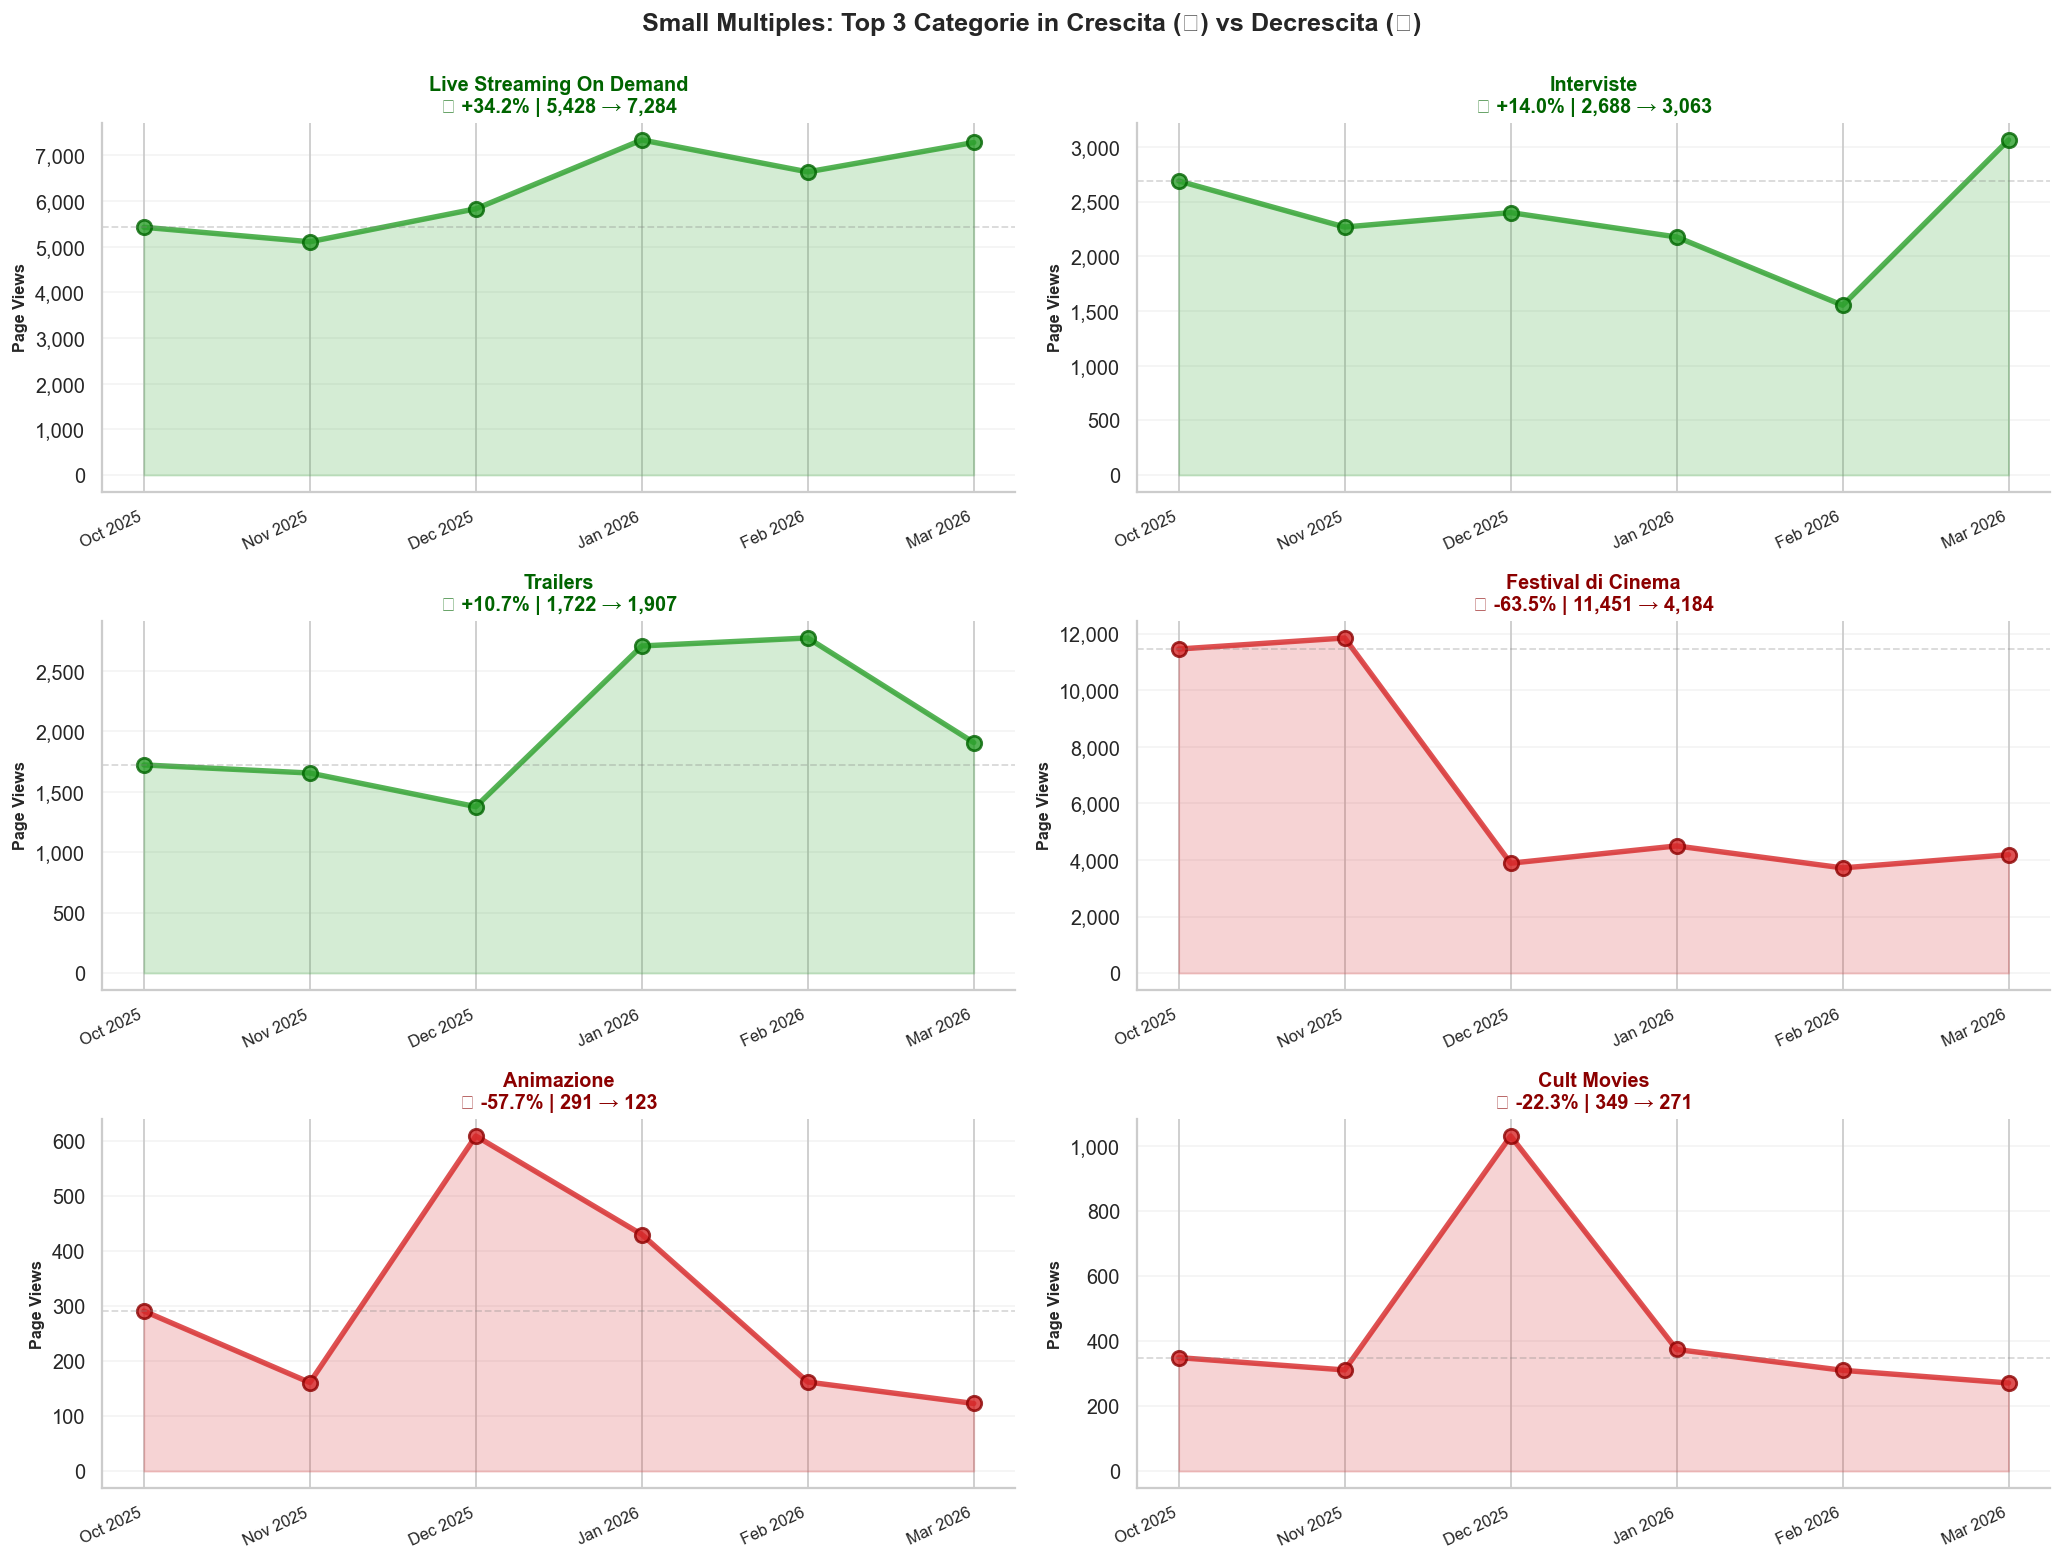



📋 TABELLA DI CONFRONTO: Primi vs Ultimi Valori di PV
               Categoria  Primo Mese  Ultimo Mese  Delta Assoluto Delta %       Tipo
Live Streaming On Demand        5428         7284            1856  +34.2% 🟢 CRESCITA
              Interviste        2688         3063             375  +14.0% 🟢 CRESCITA
                Trailers        1722         1907             185  +10.7% 🟢 CRESCITA
      Festival di Cinema       11451         4184           -7267  -63.5%     🔴 CALO
              Animazione         291          123            -168  -57.7%     🔴 CALO
             Cult Movies         349          271             -78  -22.3%     🔴 CALO


📈 VOLATILITÀ MENSILE: Variazione % mese su mese (top 6 categorie)

category   Live Streaming On Demand  Interviste   Trailers  Festival di Cinema  Animazione  Cult Movies
monthDate                                                                                              
Oct 2025                        NaN         NaN        NaN               

In [32]:
# --- Small Multiples: Top 6 categorie (3 crescita + 3 decrescita) ---

print("\n📊 ANALISI DETTAGLIATA DELLE CATEGORIE:")
print("="*70)

# Seleziona top 3 in crescita e top 3 in decrescita
top_3_growth = trend_df.tail(3).index.tolist()[::-1]  # inverti per mettere il più grande primo
top_3_decline = trend_df.head(3).index.tolist()  # top 3 nel calo

print(f"\n🟢 TOP 3 CATEGORIE IN CRESCITA:")
for i, cat in enumerate(top_3_growth, 1):
    val = trend_df.loc[cat, "delta_pct"]
    pv_first = trend_df.loc[cat, "views_primo_mese"]
    pv_last = trend_df.loc[cat, "views_ultimo_mese"]
    print(f"   {i}. {cat:30s} → {val:+6.1f}% ({pv_first:,.0f} → {pv_last:,.0f})")

print(f"\n🔴 TOP 3 CATEGORIE IN DECRESCITA:")
for i, cat in enumerate(top_3_decline, 1):
    val = trend_df.loc[cat, "delta_pct"]
    pv_first = trend_df.loc[cat, "views_primo_mese"]
    pv_last = trend_df.loc[cat, "views_ultimo_mese"]
    print(f"   {i}. {cat:30s} → {val:+6.1f}% ({pv_first:,.0f} → {pv_last:,.0f})")

# --- Crea small multiples (3 righe x 2 colonne) ---
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes_flat = axes.flatten()

# Left column: Top 3 growth (in alto)
for idx, cat in enumerate(top_3_growth):
    ax = axes_flat[idx]
    cat_data = pivot[cat]
    months = pivot.index
    x_pos = range(len(cat_data))
    
    # Colore gradiente: crescita (verde)
    color = '#2ca02c'
    linewidth = 3
    marker_size = 8
    
    ax.plot(x_pos, cat_data.values, marker='o', linewidth=linewidth, markersize=marker_size,
            color=color, alpha=0.8, markeredgecolor='darkgreen', markeredgewidth=1.5)
    ax.fill_between(x_pos, cat_data.values, alpha=0.2, color=color)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(months, rotation=25, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    
    # Calcola delta
    delta_val = trend_df.loc[cat, "delta_pct"]
    first_val = cat_data.iloc[0]
    last_val = cat_data.iloc[-1]
    
    ax.set_title(f"{cat}\n📈 +{delta_val:.1f}% | {first_val:,.0f} → {last_val:,.0f}", 
                 fontweight='bold', fontsize=11, color='darkgreen')
    
    # Linea di riferimento
    ax.axhline(first_val, color='gray', linestyle='--', alpha=0.3, linewidth=1)
    
    ax.grid(axis='y', alpha=0.2)
    ax.set_ylabel('Page Views', fontweight='bold', fontsize=9)
    sns.despine(ax=ax)

# Right column: Top 3 decline (in alto)
for idx, cat in enumerate(top_3_decline):
    ax = axes_flat[3 + idx]
    cat_data = pivot[cat]
    months = pivot.index
    x_pos = range(len(cat_data))
    
    # Colore gradiente: decrescita (rosso)
    color = '#d62728'
    linewidth = 3
    marker_size = 8
    
    ax.plot(x_pos, cat_data.values, marker='o', linewidth=linewidth, markersize=marker_size,
            color=color, alpha=0.8, markeredgecolor='darkred', markeredgewidth=1.5)
    ax.fill_between(x_pos, cat_data.values, alpha=0.2, color=color)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(months, rotation=25, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    
    # Calcola delta
    delta_val = trend_df.loc[cat, "delta_pct"]
    first_val = cat_data.iloc[0]
    last_val = cat_data.iloc[-1]
    
    ax.set_title(f"{cat}\n📉 {delta_val:.1f}% | {first_val:,.0f} → {last_val:,.0f}", 
                 fontweight='bold', fontsize=11, color='darkred')
    
    # Linea di riferimento
    ax.axhline(first_val, color='gray', linestyle='--', alpha=0.3, linewidth=1)
    
    ax.grid(axis='y', alpha=0.2)
    ax.set_ylabel('Page Views', fontweight='bold', fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('Small Multiples: Top 3 Categorie in Crescita (🟢) vs Decrescita (🔴)', 
             fontsize=14, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

# --- Tabella di confronto dettagliato ---
print(f"\n\n📋 TABELLA DI CONFRONTO: Primi vs Ultimi Valori di PV")
print("="*70)

comparison_data = []
for cat in top_3_growth + top_3_decline:
    row = trend_df.loc[cat]
    comparison_data.append({
        'Categoria': cat,
        'Primo Mese': int(row['views_primo_mese']),
        'Ultimo Mese': int(row['views_ultimo_mese']),
        'Delta Assoluto': int(row['delta_assoluto']),
        'Delta %': f"{row['delta_pct']:+.1f}%",
        'Tipo': '🟢 CRESCITA' if row['delta_pct'] > 0 else '🔴 CALO'
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# --- Varianza month-over-month per questi top 6 ---
print(f"\n\n📈 VOLATILITÀ MENSILE: Variazione % mese su mese (top 6 categorie)")
print("="*70)

top_6_cats = top_3_growth + top_3_decline
pct_change_top6 = pct_change[top_6_cats]

print("\n" + pct_change_top6.to_string())

# Calcola statistiche di volatilità
print(f"\n\n🎯 STATISTICHE DI VOLATILITÀ (std dev delle variazioni MoM):")
volatility = pct_change_top6.std().sort_values(ascending=False)
for cat, vol in volatility.items():
    volatility_type = "Alto" if vol > 15 else ("Medio" if vol > 8 else "Basso")
    print(f"   {cat:30s} → σ = {vol:6.2f}%  ({volatility_type})")